In [1]:
import ast      
import random 
from collections import deque
import warnings

import math 

import numpy as np
import pandas as pd
from pandas.api.types import is_numeric_dtype, is_bool_dtype

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import plotly.express as px
from tabulate import tabulate

from scipy.stats import gmean, hmean, kurtosis, skew
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.cluster import (
    AgglomerativeClustering,
    DBSCAN,
    KMeans
)
import hdbscan
from sklearn.base import BaseEstimator, ClusterMixin

from sklearn.metrics import (
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score
)

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap.umap_ as umap
import gower

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import NearestNeighbors

import torch
import torch.optim as optim

from dython.nominal import associations

In [2]:
SEED=42
random.seed(SEED)
np.random.seed(SEED)

In [3]:
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.cluster._kmeans")
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message="n_jobs value .* overridden to 1.*")

In [4]:
df_original = pd.read_csv('../data/university_student_retention_dataset_2134.csv')

In [5]:
df_original.columns

Index(['student_id', 'age', 'gender', 'ethnicity', 'major', 'gpa_current',
       'gpa_history', 'attendance_rate', 'enrollment_gap_months',
       'credits_completed', 'financial_aid_status', 'academic_warning_count',
       'advisor_meeting_count', 'advising_notes', 'counseling_notes',
       'gpa_by_semester', 'attendance_by_semester', 'dropout_risk',
       'next_semester_dropout', 'dropout_type', 'dropout_duration',
       'dropout_cause'],
      dtype='object')

In [6]:
df_original.head(5)

,student_id,age,gender,ethnicity,major,gpa_current,gpa_history,attendance_rate,enrollment_gap_months,credits_completed,...,advisor_meeting_count,advising_notes,counseling_notes,gpa_by_semester,attendance_by_semester,dropout_risk,next_semester_dropout,dropout_type,dropout_duration,dropout_cause
0,S1000,21,Other,Black,Psychology,3.17,2.77,0.88,0,42,...,2,Student discussed academic goals and current c...,Reported stress and difficulty with time manag...,"[2.44, 2.24, 3.12, 2.32]","[0.82, 0.8, 0.78, 0.69]",False,False,NaN,0,NaN
1,S1001,26,Male,Hispanic,Business,2.99,2.72,0.72,3,109,...,5,Student discussed academic goals and current c...,NaN,"[3.11, 3.4, 2.75, 2.86]","[0.98, 0.92, 0.96, 0.91]",False,False,NaN,0,NaN
2,S1002,26,Other,Black,Psychology,2.45,2.25,0.79,1,119,...,5,Student discussed academic goals and current c...,NaN,"[3.37, 3.29, 2.8, 3.56]","[0.72, 0.95, 0.54, 0.98]",False,False,NaN,0,NaN
3,S1003,21,Other,Asian,Psychology,3.82,3.79,0.97,3,38,...,4,Student discussed academic goals and current c...,NaN,"[3.04, 2.81, 3.18, 3.82]","[0.77, 0.79, 0.54, 0.86]",False,False,NaN,0,NaN
4,S1004,19,Male,Hispanic,Electrical Engineering,2.18,1.97,0.56,0,26,...,1,Student discussed academic goals and current c...,NaN,"[3.5, 1.96, 2.24, 3.48]","[0.59, 0.96, 0.71, 0.54]",True,True,Permanent,0,Financial


In [7]:
df_original.shape

(2134, 22)

In [8]:
df_original.dtypes

student_id                 object
age                         int64
gender                     object
ethnicity                  object
major                      object
gpa_current               float64
gpa_history               float64
attendance_rate           float64
enrollment_gap_months       int64
credits_completed           int64
financial_aid_status         bool
academic_warning_count      int64
advisor_meeting_count       int64
advising_notes             object
counseling_notes           object
gpa_by_semester            object
attendance_by_semester     object
dropout_risk                 bool
next_semester_dropout        bool
dropout_type               object
dropout_duration            int64
dropout_cause              object
dtype: object

In [9]:
df_original.dtypes.value_counts()

object     10
int64       6
float64     3
bool        3
Name: count, dtype: int64

In [10]:
df_original.describe(include=['object'])

,student_id,gender,ethnicity,major,advising_notes,counseling_notes,gpa_by_semester,attendance_by_semester,dropout_type,dropout_cause
count,2134,2134,2134,2134,2134,653,2134,2134,598,598
unique,2134,3,5,5,1,1,2134,2134,3,4
top,S1000,Female,Asian,Business,Student discussed academic goals and current c...,Reported stress and difficulty with time manag...,"[2.44, 2.24, 3.12, 2.32]","[0.82, 0.8, 0.78, 0.69]",Permanent,Academic
freq,1,731,440,456,2134,653,1,1,221,156


In [11]:
df_updated = df_original.copy()
df_updated.drop(columns=['student_id', 'counseling_notes', 'advising_notes'], inplace=True)

In [12]:
logical_df = df_updated.select_dtypes(include="bool")
numeric_df = df_updated.select_dtypes(include="number")
categorical_df = df_updated.select_dtypes(exclude=["number", "bool"])

In [13]:
def values(dataset:pd.DataFrame):
    for col in dataset.columns:
        temp=pd.unique(dataset[col])
        print(f'{col}: {temp}')

In [14]:
values(categorical_df)

gender: ['Other' 'Male' 'Female']
ethnicity: ['Black' 'Hispanic' 'Asian' 'White' 'Other']
major: ['Psychology' 'Business' 'Electrical Engineering' 'Computer Science'
 'Biology']
gpa_by_semester: ['[2.44, 2.24, 3.12, 2.32]' '[3.11, 3.4, 2.75, 2.86]'
 '[3.37, 3.29, 2.8, 3.56]' ... '[3.23, 3.74, 3.2, 2.6]'
 '[3.64, 2.05, 3.05, 2.87]' '[3.43, 3.29, 2.88, 3.29]']
attendance_by_semester: ['[0.82, 0.8, 0.78, 0.69]' '[0.98, 0.92, 0.96, 0.91]'
 '[0.72, 0.95, 0.54, 0.98]' ... '[0.97, 0.98, 0.66, 0.68]'
 '[0.87, 0.85, 0.91, 0.66]' '[0.69, 0.65, 0.93, 0.71]']
dropout_type: [nan 'Permanent' 'Temporary' 'Transfer']
dropout_cause: [nan 'Financial' 'Academic' 'Other' 'Mental Health']


In [15]:
type(categorical_df["gpa_by_semester"].iloc[0])

str

In [16]:
df_updated["gpa_by_semester"] = df_updated["gpa_by_semester"].apply(ast.literal_eval)
df_updated["attendance_by_semester"] = df_updated["attendance_by_semester"].apply(ast.literal_eval)

gpa_len = df_updated["gpa_by_semester"].apply(lambda x: len(x) if isinstance(x, (list, tuple)) else None)
print(gpa_len.value_counts())

attendance_len = df_updated["attendance_by_semester"].apply(lambda x: len(x) if isinstance(x, (list, tuple)) else None)
print(attendance_len.value_counts())

gpa_by_semester
4    2134
Name: count, dtype: int64
attendance_by_semester
4    2134
Name: count, dtype: int64


In [17]:
gpa_expanded = pd.DataFrame(df_updated["gpa_by_semester"].tolist(),
                            columns=[f"GPA_sem{i+1}" for i in range(len(df_updated["gpa_by_semester"].iloc[0]))])

attendance_expanded = pd.DataFrame(df_updated["attendance_by_semester"].tolist(),
                                   columns=[f"Attendance_sem{i+1}" for i in range(len(df_updated["attendance_by_semester"].iloc[0]))])

df_updated = pd.concat([df_updated.drop(["gpa_by_semester", "attendance_by_semester"], axis=1),
                              gpa_expanded, attendance_expanded], axis=1)

df_updated.dtypes

age                         int64
gender                     object
ethnicity                  object
major                      object
gpa_current               float64
gpa_history               float64
attendance_rate           float64
enrollment_gap_months       int64
credits_completed           int64
financial_aid_status         bool
academic_warning_count      int64
advisor_meeting_count       int64
dropout_risk                 bool
next_semester_dropout        bool
dropout_type               object
dropout_duration            int64
dropout_cause              object
GPA_sem1                  float64
GPA_sem2                  float64
GPA_sem3                  float64
GPA_sem4                  float64
Attendance_sem1           float64
Attendance_sem2           float64
Attendance_sem3           float64
Attendance_sem4           float64
dtype: object

In [18]:
df_updated.isnull().sum()

age                          0
gender                       0
ethnicity                    0
major                        0
gpa_current                  0
gpa_history                  0
attendance_rate              0
enrollment_gap_months        0
credits_completed            0
financial_aid_status         0
academic_warning_count       0
advisor_meeting_count        0
dropout_risk                 0
next_semester_dropout        0
dropout_type              1536
dropout_duration             0
dropout_cause             1536
GPA_sem1                     0
GPA_sem2                     0
GPA_sem3                     0
GPA_sem4                     0
Attendance_sem1              0
Attendance_sem2              0
Attendance_sem3              0
Attendance_sem4              0
dtype: int64

In [19]:
def unique_when_nan(df, kolona_nan, kolona_unique):
    return df[df[kolona_nan].isna()][kolona_unique].dropna().unique()

In [20]:
df_check = df_updated.copy()

print(unique_when_nan(df_check, "dropout_type", "dropout_duration"),
unique_when_nan(df_check, "dropout_cause", "dropout_duration"))

[0] [0]


In [21]:
def unique_when_zero(df, kolona_zero, kolona_unique):
    return df[df[kolona_zero] == 0][kolona_unique].dropna().unique()

In [22]:
print(unique_when_nan(df_check, "dropout_duration", "dropout_cause"),
unique_when_nan(df_check, "dropout_duration", "dropout_type"))

[] []


In [23]:
df_imputed = df_updated.copy()

df_imputed['dropout_type'] = df_imputed['dropout_type'].fillna("None")
df_imputed['dropout_cause'] = df_imputed['dropout_cause'].fillna("None")

df_imputed.isnull().sum()

age                       0
gender                    0
ethnicity                 0
major                     0
gpa_current               0
gpa_history               0
attendance_rate           0
enrollment_gap_months     0
credits_completed         0
financial_aid_status      0
academic_warning_count    0
advisor_meeting_count     0
dropout_risk              0
next_semester_dropout     0
dropout_type              0
dropout_duration          0
dropout_cause             0
GPA_sem1                  0
GPA_sem2                  0
GPA_sem3                  0
GPA_sem4                  0
Attendance_sem1           0
Attendance_sem2           0
Attendance_sem3           0
Attendance_sem4           0
dtype: int64

In [24]:
def geometric_mean(df, value_col):
    values = df[value_col]
    values = values[values > 0]
    if len(values) == 0:
        return np.nan
    return gmean(values)

In [25]:
def harmonic_mean(df, value_col):
    values = df[value_col]
    values = values[values > 0]
    if len(values) == 0:
        return np.nan
    return hmean(values)

In [26]:
def custom_describe(df):
    results = []
    
    numeric_cols = set([
        col for col in df.columns 
        if is_numeric_dtype(df[col]) and not is_bool_dtype(df[col])
    ])
    
    non_numeric_cols = set(df.columns) - numeric_cols

    for col in df.columns:
        values = df[col].dropna()
        
        if col in numeric_cols:
            positive_values = values[values > 0] 
            
            g_mean = gmean(positive_values) if len(positive_values) > 0 else np.nan
            h_mean = hmean(positive_values) if len(positive_values) > 0 else np.nan
            
            results.append({
                'Kolona': col,
                'count': values.count(),
                'mean': values.mean(),
                'std': values.std(),
                'min': values.min(),
                '25%': values.quantile(0.25), 
                '50%': values.median(),
                '75%': values.quantile(0.75),
                'max': values.max(),
                'Geometrijska sredina': g_mean,
                'Harmonijska sredina': h_mean,
                'Skewness': skew(values.values),
                'Kurtosis': kurtosis(values.values),
                'modal_value': " " 
            })
        
        elif col in non_numeric_cols:
            try:
                mode = values.mode().iloc[0] 
            except IndexError:
                mode = " "
                
            results.append({
                'Kolona': col,
                'count': values.count(),
                'mean': " ", 'std': " ", 'min': " ", '25%': " ",
                '50%': " ", '75%': " ", 'max': " ",
                'Geometrijska sredina': " ", 'Harmonijska sredina': " ",
                'Skewness': " ", 'Kurtosis': " ",
                'modal_value': mode 
            })

    result_df = pd.DataFrame(results)
    
    if 'modal_value' in result_df.columns:
        cols = [col for col in result_df.columns if col != 'modal_value'] + ['modal_value']
        result_df = result_df[cols]

    def highlight_column_type(val):
        if val in numeric_cols:
            return 'color: green'
        else:
            return 'color: blue' 

    styled_df = result_df.style.map(highlight_column_type, subset=['Kolona'])

    styled_df.set_caption("Legenda: 🟩 = numeričke kolone, 🟦 = ne numeričke kolone")
    
    styled_df = styled_df.format(precision=3)
    
    return styled_df

In [27]:
custom_describe(df_imputed)

,Kolona,count,mean,std,min,25%,50%,75%,max,Geometrijska sredina,Harmonijska sredina,Skewness,Kurtosis,modal_value
0,age,2134,23.399,3.446,18,20.000,23.000,26.000,29,23.143,22.886,0.050,-1.200,
1,gender,2134,,,,,,,,,,,,Female
2,ethnicity,2134,,,,,,,,,,,,Asian
3,major,2134,,,,,,,,,,,,Business
4,gpa_current,2134,2.757,0.720,1.500,2.140,2.770,3.370,4.000,2.658,2.557,-0.013,-1.191,
5,gpa_history,2134,2.503,0.738,1.050,1.890,2.490,3.120,3.990,2.387,2.266,0.008,-1.107,
6,attendance_rate,2134,0.753,0.144,0.500,0.640,0.750,0.870,1.000,0.739,0.725,0.020,-1.163,
7,enrollment_gap_months,2134,0.993,1.141,0,0.000,1.000,2.000,3,1.784,1.607,0.658,-1.086,
8,credits_completed,2134,69.871,29.009,20,44.000,71.000,95.000,119,62.927,55.430,-0.017,-1.225,
9,financial_aid_status,2134,,,,,,,,,,,,True


In [28]:
numeric_df = df_imputed.select_dtypes(include="number")
categorical_df = df_imputed.select_dtypes(exclude=["number", "bool"])

num_cols = numeric_df.columns

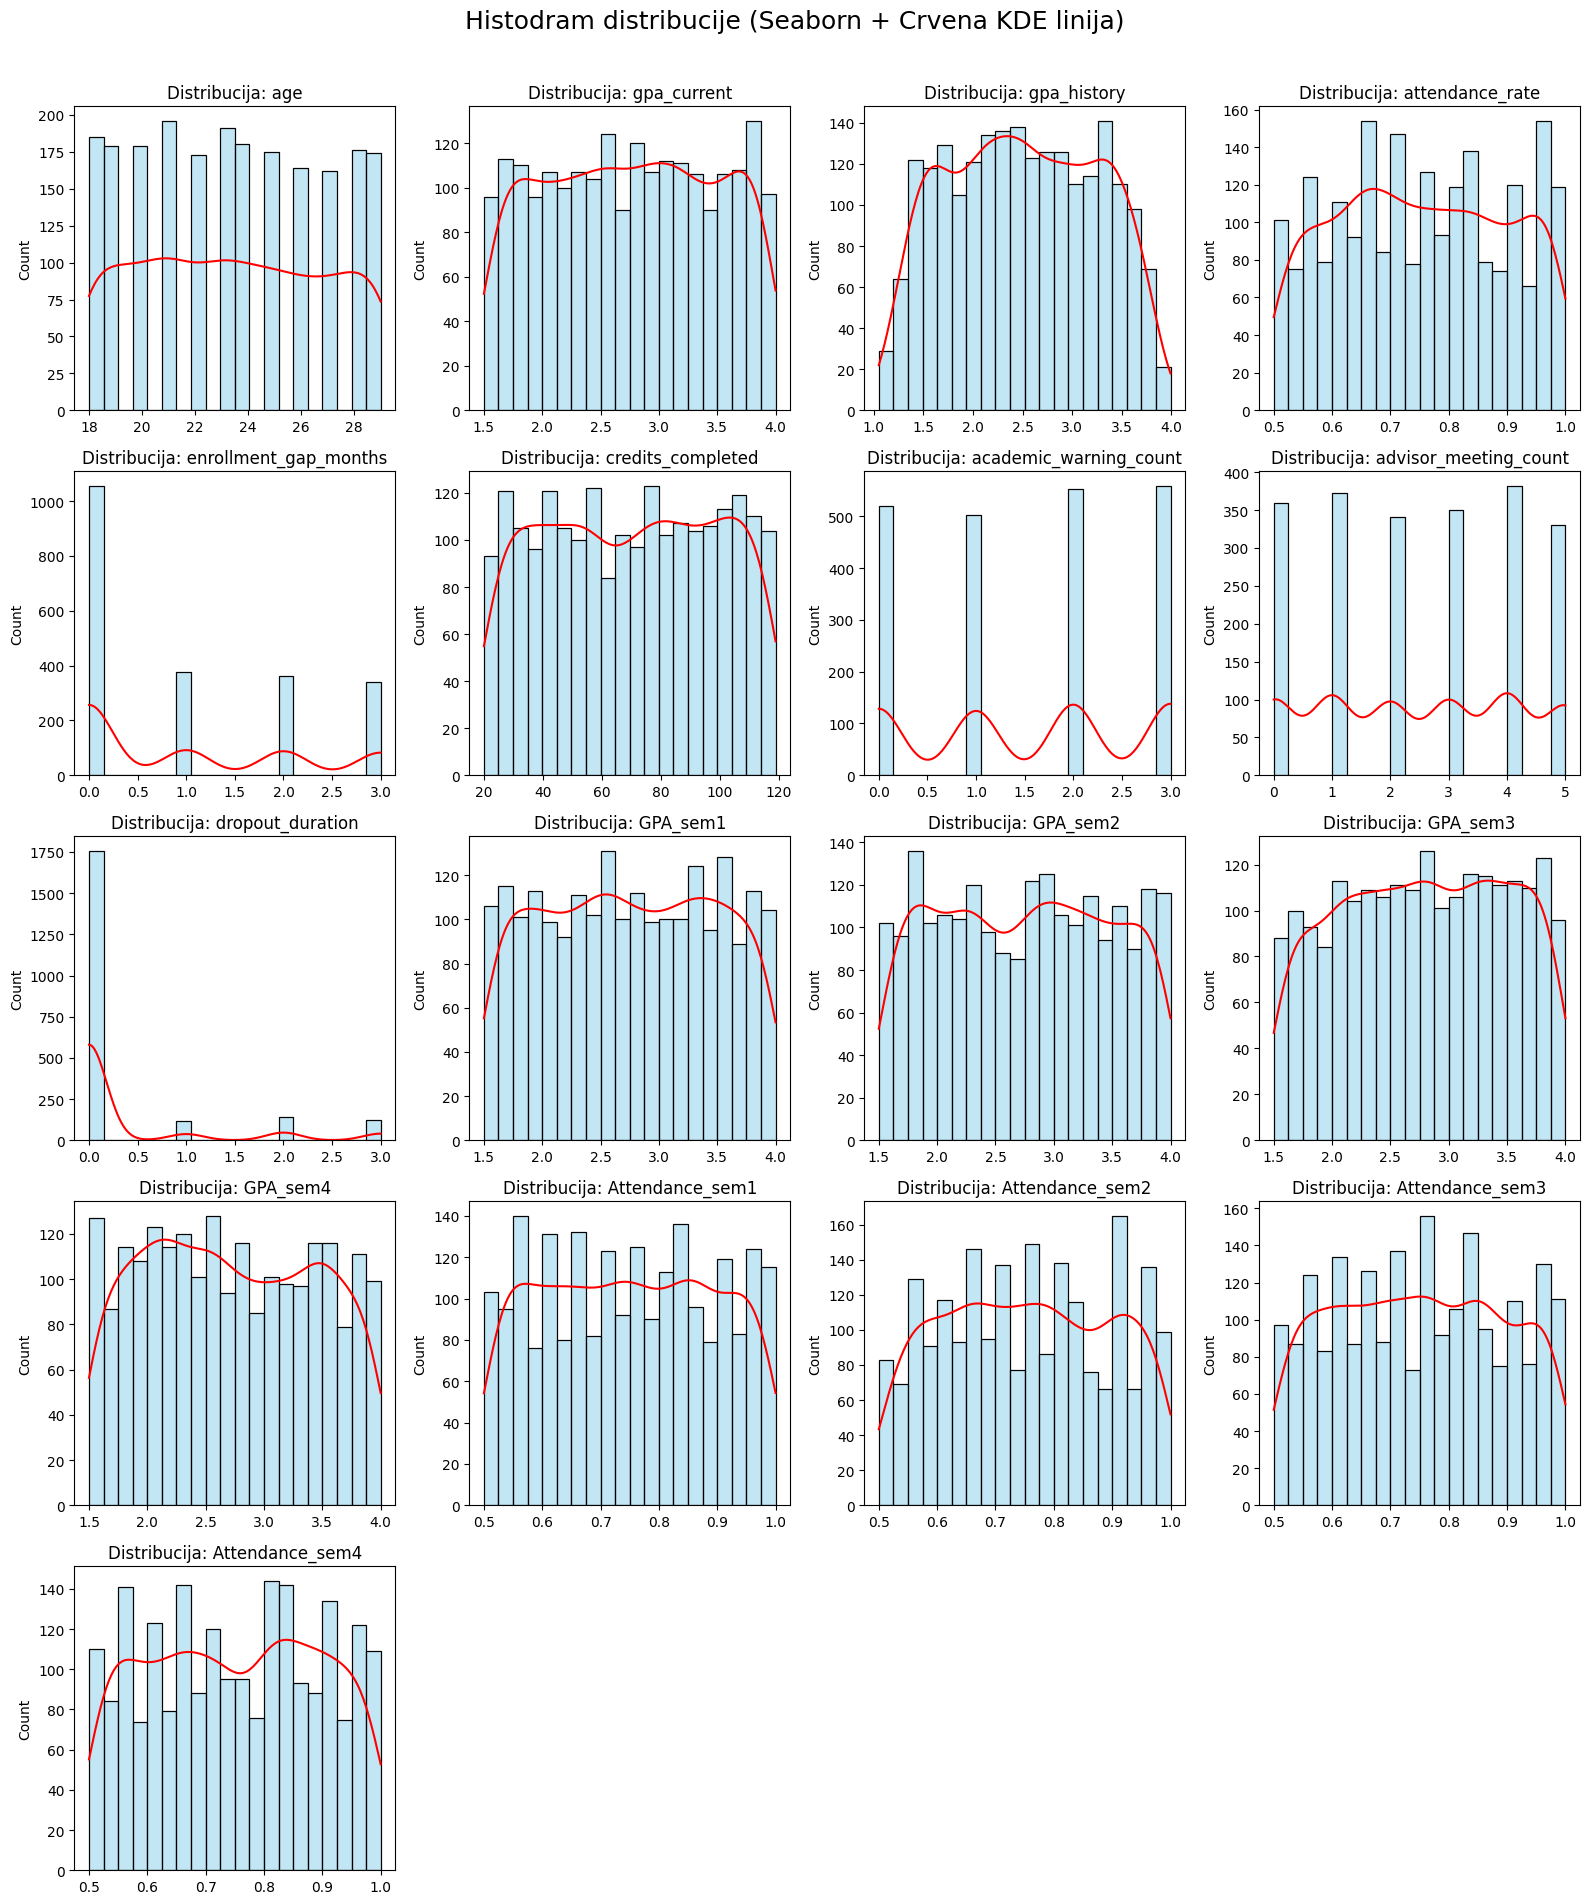

In [29]:
num_plots = len(num_cols)

KOLONE_PO_REDU = 4
redovi = math.ceil(num_plots / KOLONE_PO_REDU)
layout_tuple = (redovi, KOLONE_PO_REDU)

FIGSIZE = (KOLONE_PO_REDU * 4, redovi * 4)

fig, axes = plt.subplots(redovi, KOLONE_PO_REDU, figsize=FIGSIZE)

if redovi * KOLONE_PO_REDU > 1:
    axes = axes.flatten()
elif redovi == 1 and KOLONE_PO_REDU == 1:
    axes = [axes] 
else:
    axes = axes.ravel() 

for i, col in enumerate(num_cols):
    sns.histplot(
        data=df_imputed,
        x=col,
        ax=axes[i],        
        kde=True,
        bins=20,
        color='skyblue',
        stat='count'
    )
    
    for line in axes[i].lines:
        if line.get_linestyle() == '-' and line.get_linewidth() > 1:
            line.set_color('red')
            break
    axes[i].set_title(f'Distribucija: {col}', fontsize=12)
    axes[i].set_xlabel('') 

for i in range(num_plots, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.suptitle('Histodram distribucije (Seaborn + Crvena KDE linija)', fontsize=18, y=0.98)
plt.show()

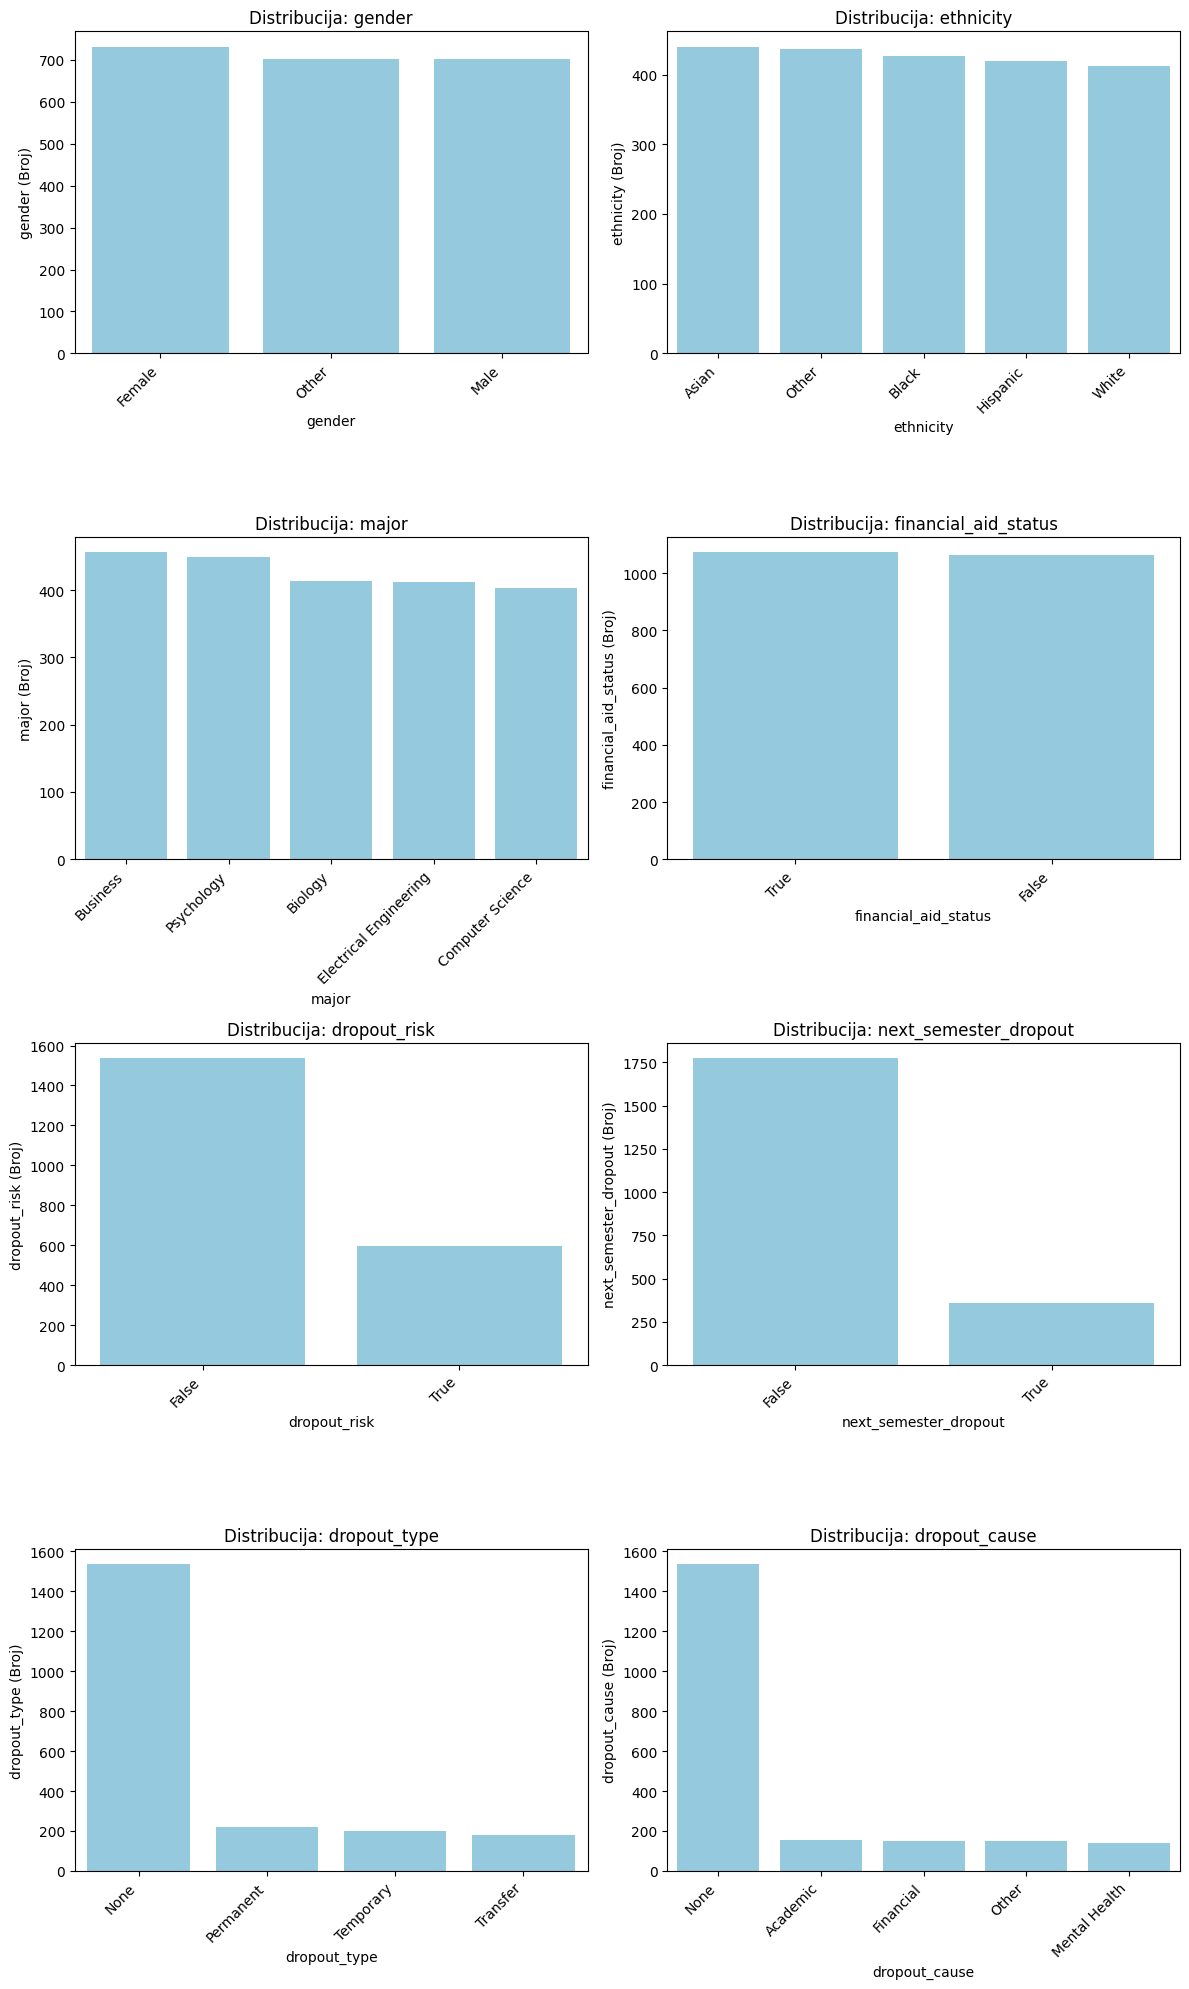

In [30]:
nonnumerical_df = df_imputed.select_dtypes(exclude="number")
cols = nonnumerical_df.columns
num_columns = len(cols)

cols_per_row = 2 
rows = (num_columns + cols_per_row - 1) // cols_per_row

plt.figure(figsize=(6 * cols_per_row, 5 * rows)) 

for i, col in enumerate(cols):
    plt.subplot(rows, cols_per_row, i + 1)
    
    sns.countplot(
            data=df_imputed,
            x=df_imputed[col].astype(str),
            color='skyblue',
            order=df_imputed[col].value_counts().index
        )
    
    plt.title(f'Distribucija: {col}')
    plt.xlabel(col)
    plt.ylabel(f'{df_imputed[col].name} (Broj)') 
    plt.xticks(rotation=45, ha='right') 

plt.tight_layout() 
plt.show()

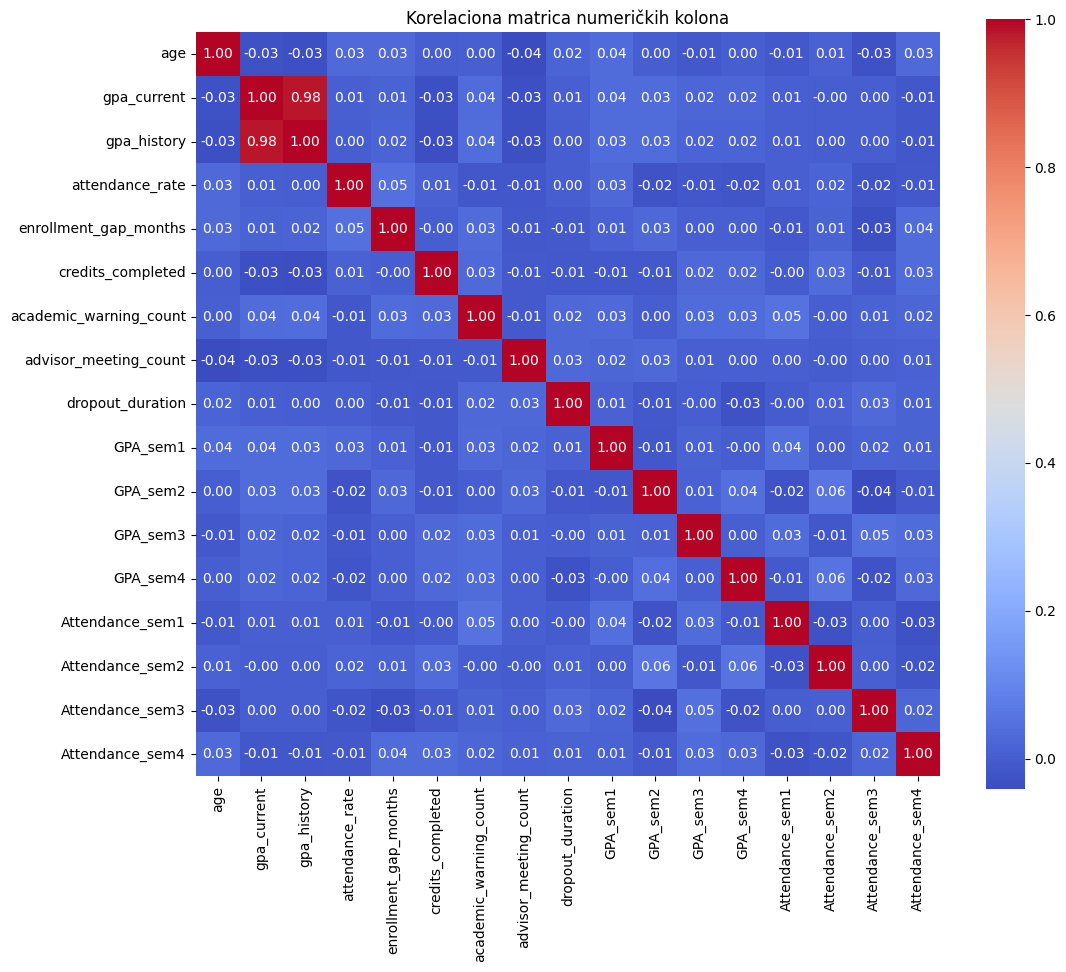

In [31]:
corr_matrix = df_imputed[num_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title("Korelaciona matrica numeričkih kolona")
plt.show()

In [32]:
df_reduced = df_imputed.copy()
df_reduced.drop(columns=['gpa_current'], inplace=True)

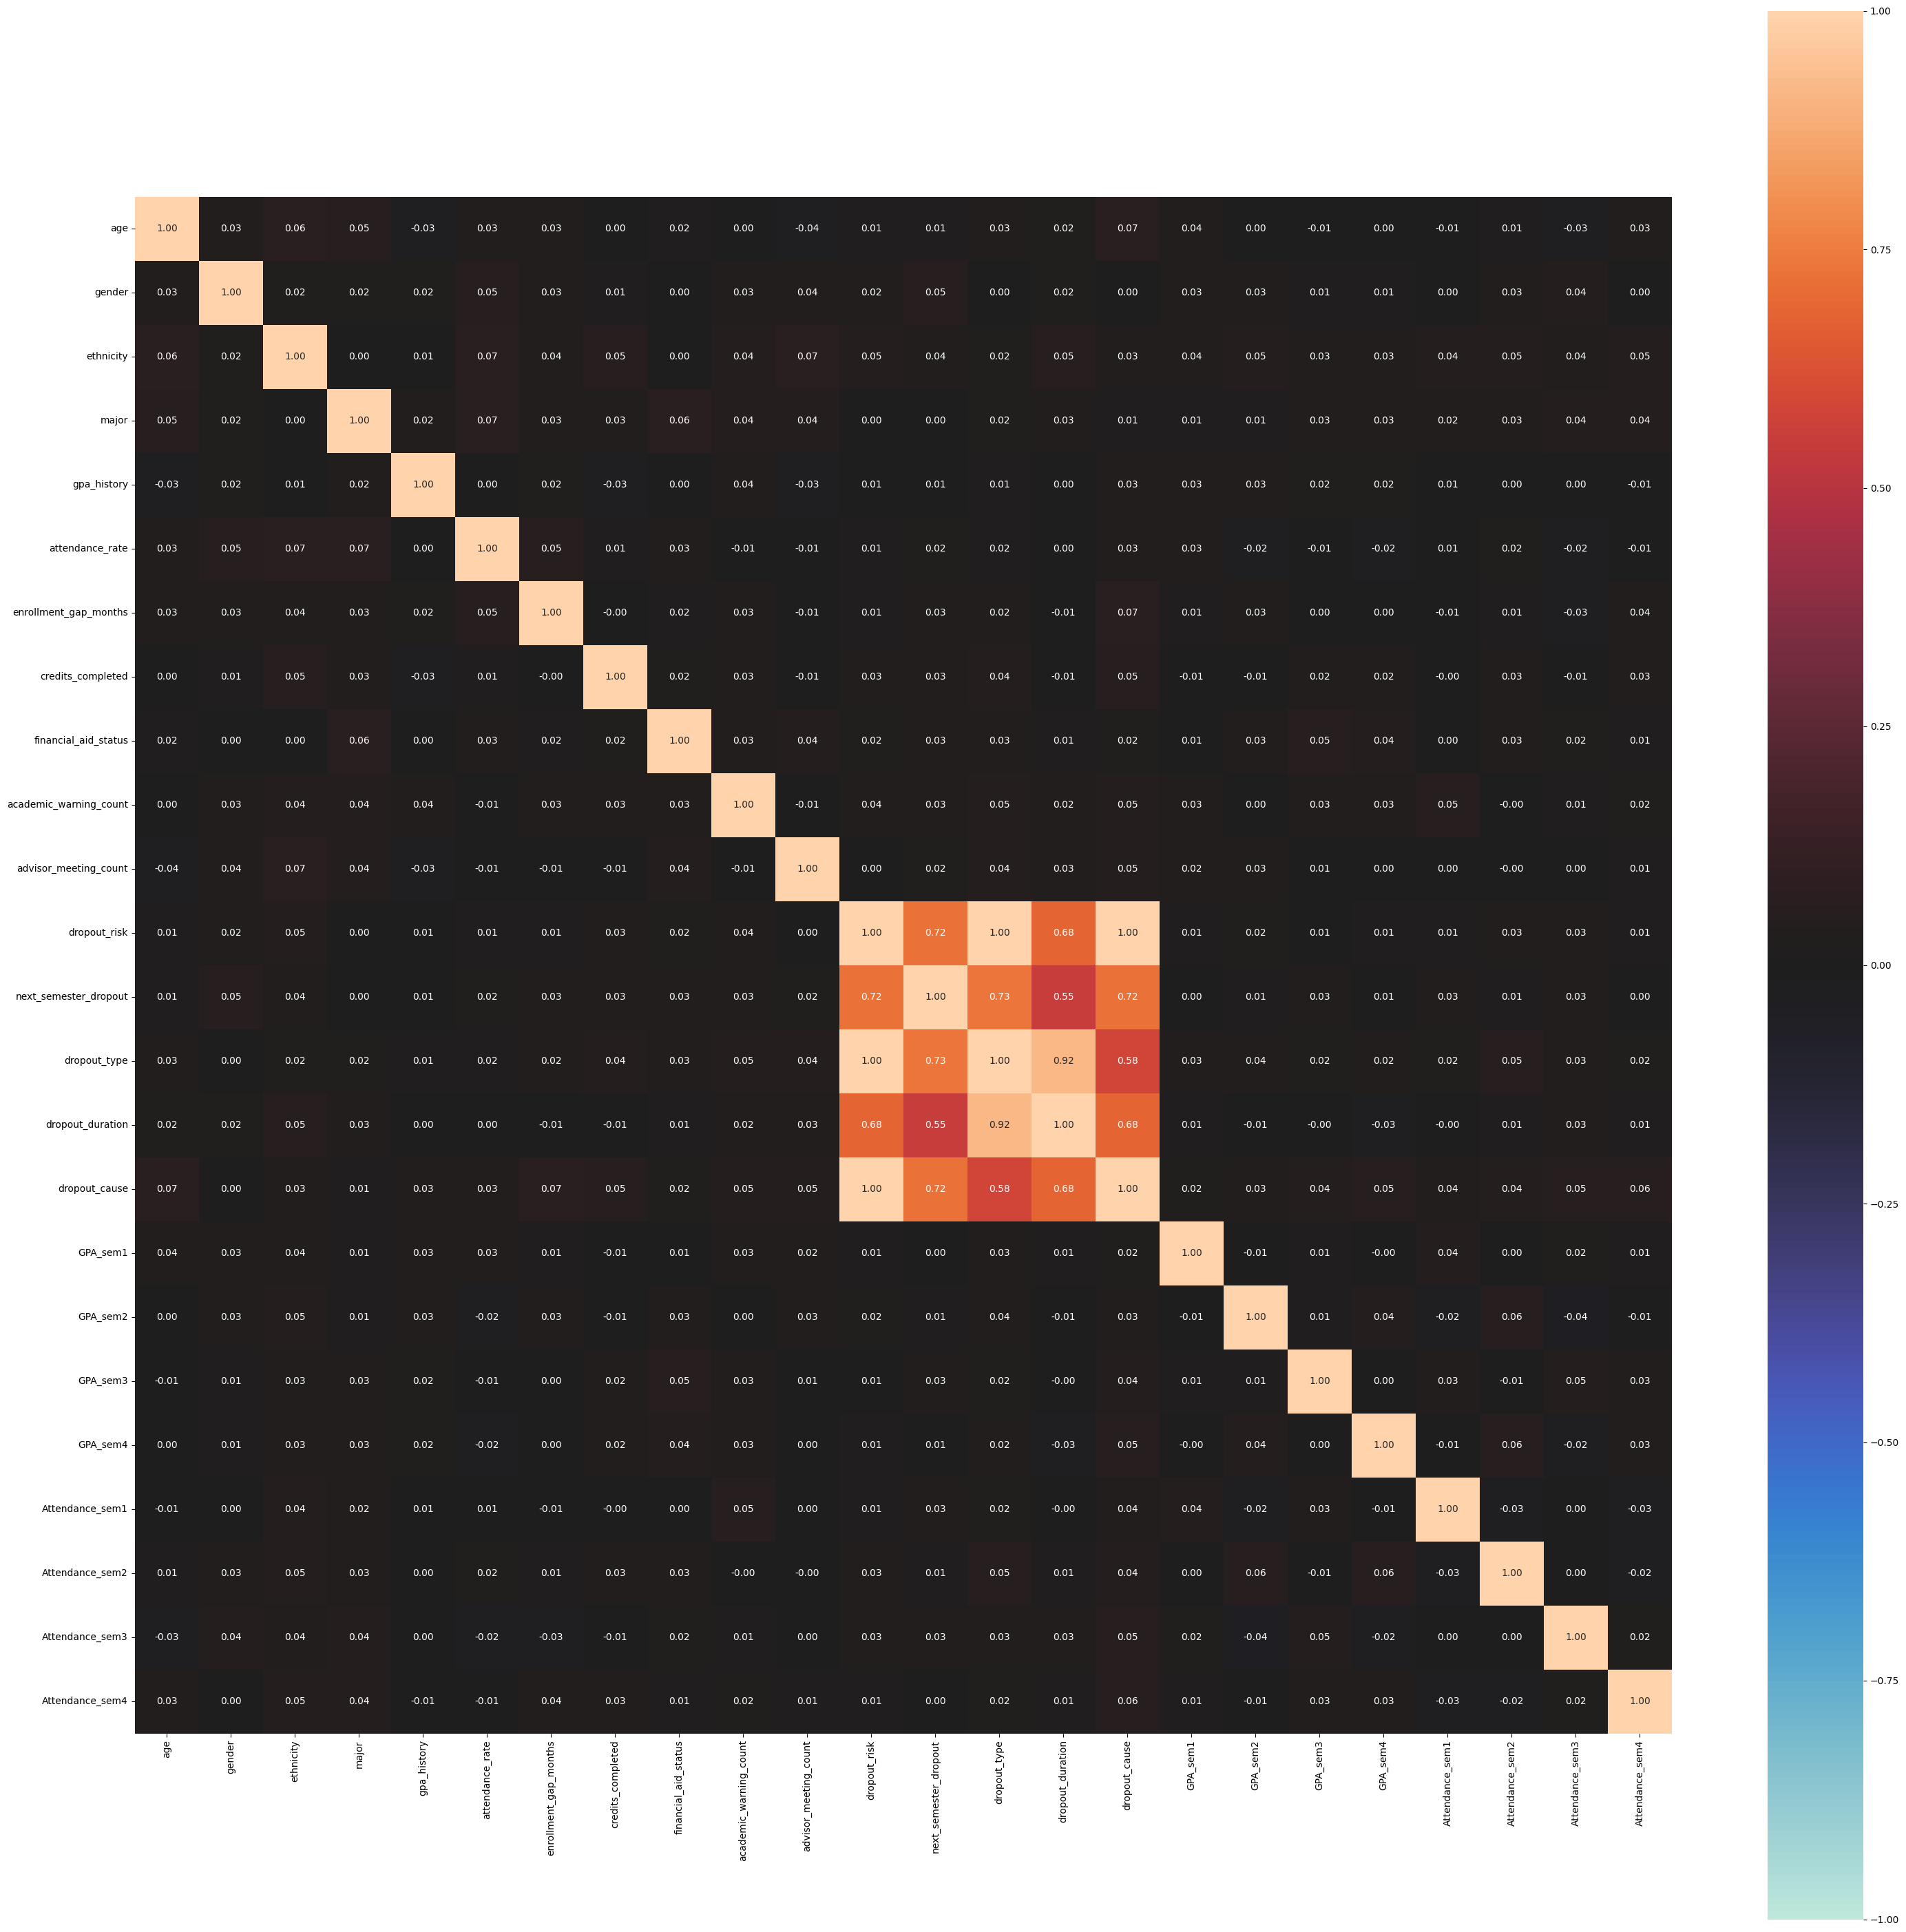

{'corr':                              age    gender  ethnicity     major  gpa_history  \
 age                     1.000000  0.034608   0.063029  0.052790    -0.029549   
 gender                  0.034608  1.000000   0.016346  0.016162     0.017140   
 ethnicity               0.063029  0.016346   1.000000  0.000000     0.006861   
 major                   0.052790  0.016162   0.000000  1.000000     0.024483   
 gpa_history            -0.029549  0.017140   0.006861  0.024483     1.000000   
 attendance_rate         0.028246  0.049881   0.069403  0.065070     0.001236   
 enrollment_gap_months   0.030761  0.025478   0.036418  0.028369     0.016506   
 credits_completed       0.003067  0.012885   0.047132  0.030030    -0.034150   
 financial_aid_status    0.015096  0.000000   0.000000  0.062979     0.003852   
 academic_warning_count  0.004048  0.029745   0.044971  0.044293     0.038401   
 advisor_meeting_count  -0.038252  0.036696   0.069275  0.042318    -0.031508   
 dropout_risk       

In [33]:
cat_cols=categorical_df.columns
logical_df = df_reduced.select_dtypes(include="bool")
bool_cols = logical_df.columns
cat_cols_list = list(cat_cols)
bool_cols_list = list(bool_cols)

nominal_cols = cat_cols_list + bool_cols_list 

associations(df_reduced, nominal_columns=nominal_cols, plot=True)

In [34]:
for i, col1 in enumerate(cols):
    for col2 in cols[i+1:]:
        cross_tab = pd.crosstab(df_reduced[col1], df_reduced[col2])
        print(f"Cross-tab između '{col1}' i '{col2}':")
        print(tabulate(cross_tab, headers='keys', tablefmt='grid'))
        print("\n" + "-"*40 + "\n")

Cross-tab između 'gender' i 'ethnicity':
+----------+---------+---------+------------+---------+---------+
| gender   |   Asian |   Black |   Hispanic |   Other |   White |
+==========+=========+=========+============+=========+=========+
| Female   |     161 |     126 |        153 |     161 |     130 |
+----------+---------+---------+------------+---------+---------+
| Male     |     139 |     150 |        131 |     136 |     145 |
+----------+---------+---------+------------+---------+---------+
| Other    |     140 |     150 |        135 |     140 |     137 |
+----------+---------+---------+------------+---------+---------+

----------------------------------------

Cross-tab između 'gender' i 'major':
+----------+-----------+------------+--------------------+--------------------------+--------------+
| gender   |   Biology |   Business |   Computer Science |   Electrical Engineering |   Psychology |
+==========+===========+============+====================+=========================

In [35]:
def desaturate_palette(base_color, n_colors):
        norm = mcolors.Normalize(vmin=0, vmax=n_colors-1)
        return sns.color_palette([sns.desaturate(base_color, norm(i)) for i in range(n_colors)])

def plot_violin_for_numeric_col(df, numeric_col, categorical_cols, base_color='blue'):
    df_viz = df.copy()

    for i in range(0, len(categorical_cols), 3):
        subset_cats = categorical_cols[i:i+3]
        n = len(subset_cats)

        fig, axes = plt.subplots(nrows=1, ncols=n, figsize=(6*n, 6), sharey=True)
        if n == 1:
            axes = [axes]

        fig.suptitle(f'Distribution of: {numeric_col}', fontsize=18, fontweight='bold')

        for j, cat_col in enumerate(subset_cats):
            df_viz['_temp_category'] = df_viz[cat_col].astype(str)  
            unique_vals = df_viz['_temp_category'].nunique()
            palette = desaturate_palette(base_color, unique_vals)

            sns.violinplot(
                data=df_viz,
                x='_temp_category',
                y=numeric_col,
                hue='_temp_category',
                palette=palette,
                legend=False,
                ax=axes[j]
            )

            axes[j].set_title(f'{numeric_col} by {cat_col}')
            axes[j].set_xlabel('')
            axes[j].set_ylabel(numeric_col if j == 0 else '')
            axes[j].tick_params(axis='x', rotation=45)

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()

    df_viz.drop(columns=['_temp_category'], inplace=True)

In [36]:
to_remove = ['dropout_duration']

violin_columns = list(['dropout_duration'])
base_colors = sns.color_palette("husl", len(violin_columns))

cols = ['dropout_risk','next_semester_dropout','dropout_type','dropout_cause']

violin_columns

['dropout_duration']

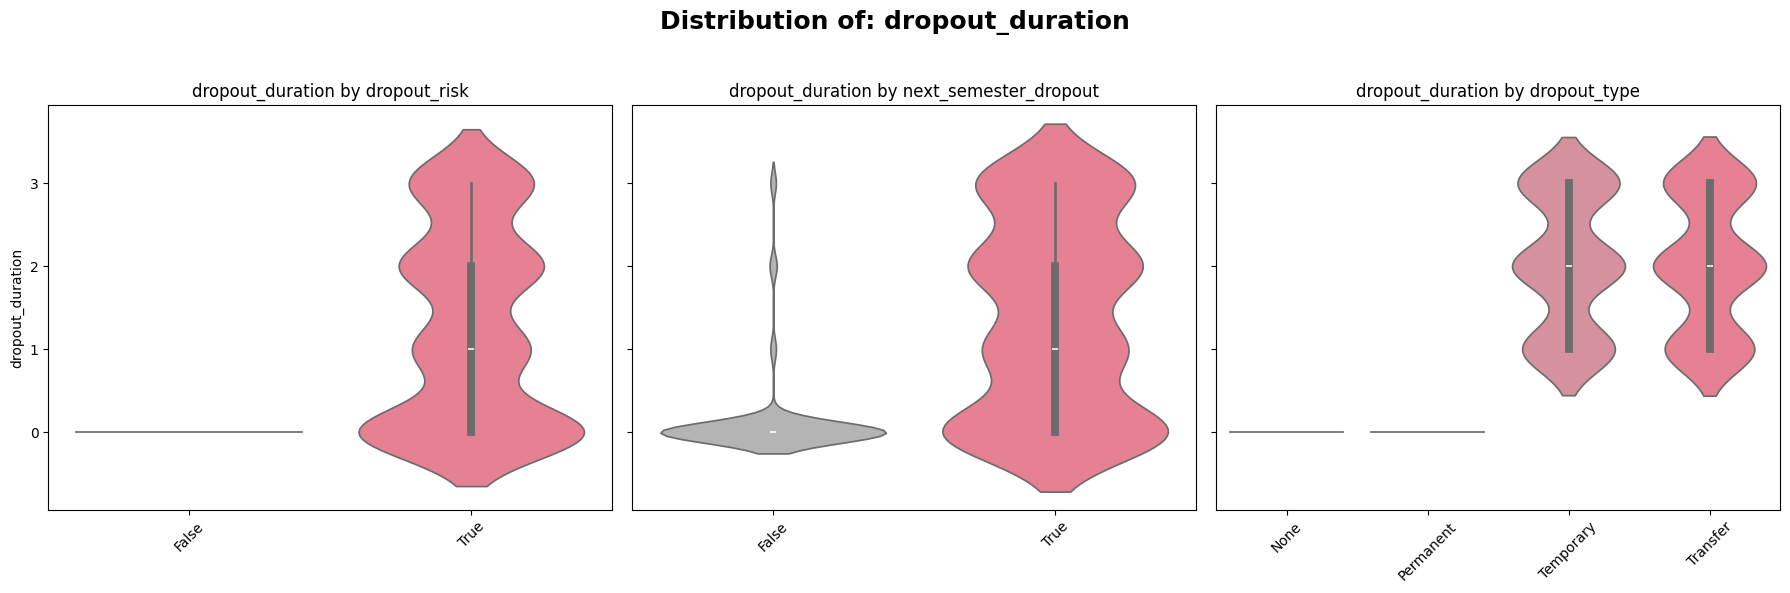

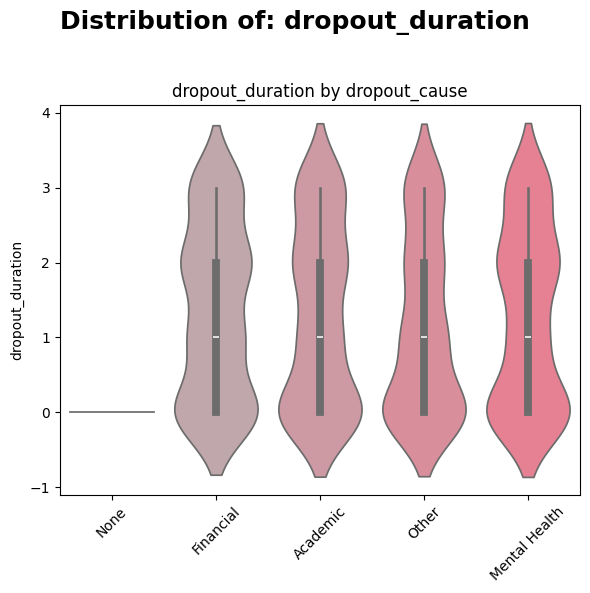

In [37]:
for i in range(len(violin_columns)):
    plot_violin_for_numeric_col(df_imputed, violin_columns[i], cols, base_colors[i])

In [38]:
to_remove = ['dropout_duration','dropout_risk','next_semester_dropout','dropout_type','dropout_cause']
df_reduced.drop(columns=to_remove, inplace=True)

In [39]:
df_reduced.dtypes

age                         int64
gender                     object
ethnicity                  object
major                      object
gpa_history               float64
attendance_rate           float64
enrollment_gap_months       int64
credits_completed           int64
financial_aid_status         bool
academic_warning_count      int64
advisor_meeting_count       int64
GPA_sem1                  float64
GPA_sem2                  float64
GPA_sem3                  float64
GPA_sem4                  float64
Attendance_sem1           float64
Attendance_sem2           float64
Attendance_sem3           float64
Attendance_sem4           float64
dtype: object

In [40]:
df_encoded = df_reduced.copy()
cat_cols = df_reduced.select_dtypes(exclude=["number", "bool"]).columns
df_encoded = pd.get_dummies(df_encoded, columns=cat_cols, drop_first=False)

In [41]:
logical_df = df_encoded.select_dtypes(include="bool")
bool_cols = logical_df.columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

In [42]:
df_encoded.dtypes

age                               int64
gpa_history                     float64
attendance_rate                 float64
enrollment_gap_months             int64
credits_completed                 int64
financial_aid_status              int32
academic_warning_count            int64
advisor_meeting_count             int64
GPA_sem1                        float64
GPA_sem2                        float64
GPA_sem3                        float64
GPA_sem4                        float64
Attendance_sem1                 float64
Attendance_sem2                 float64
Attendance_sem3                 float64
Attendance_sem4                 float64
gender_Female                     int32
gender_Male                       int32
gender_Other                      int32
ethnicity_Asian                   int32
ethnicity_Black                   int32
ethnicity_Hispanic                int32
ethnicity_Other                   int32
ethnicity_White                   int32
major_Biology                     int32


In [43]:
scaler = StandardScaler()
scaler.set_output(transform="pandas")

unchanged_values=df_encoded[bool_cols]  
df_scaled=scaler.fit_transform(df_encoded)  
df_scaled[bool_cols]=unchanged_values[bool_cols]
df = df_scaled.copy()

# Analiza outlier-a

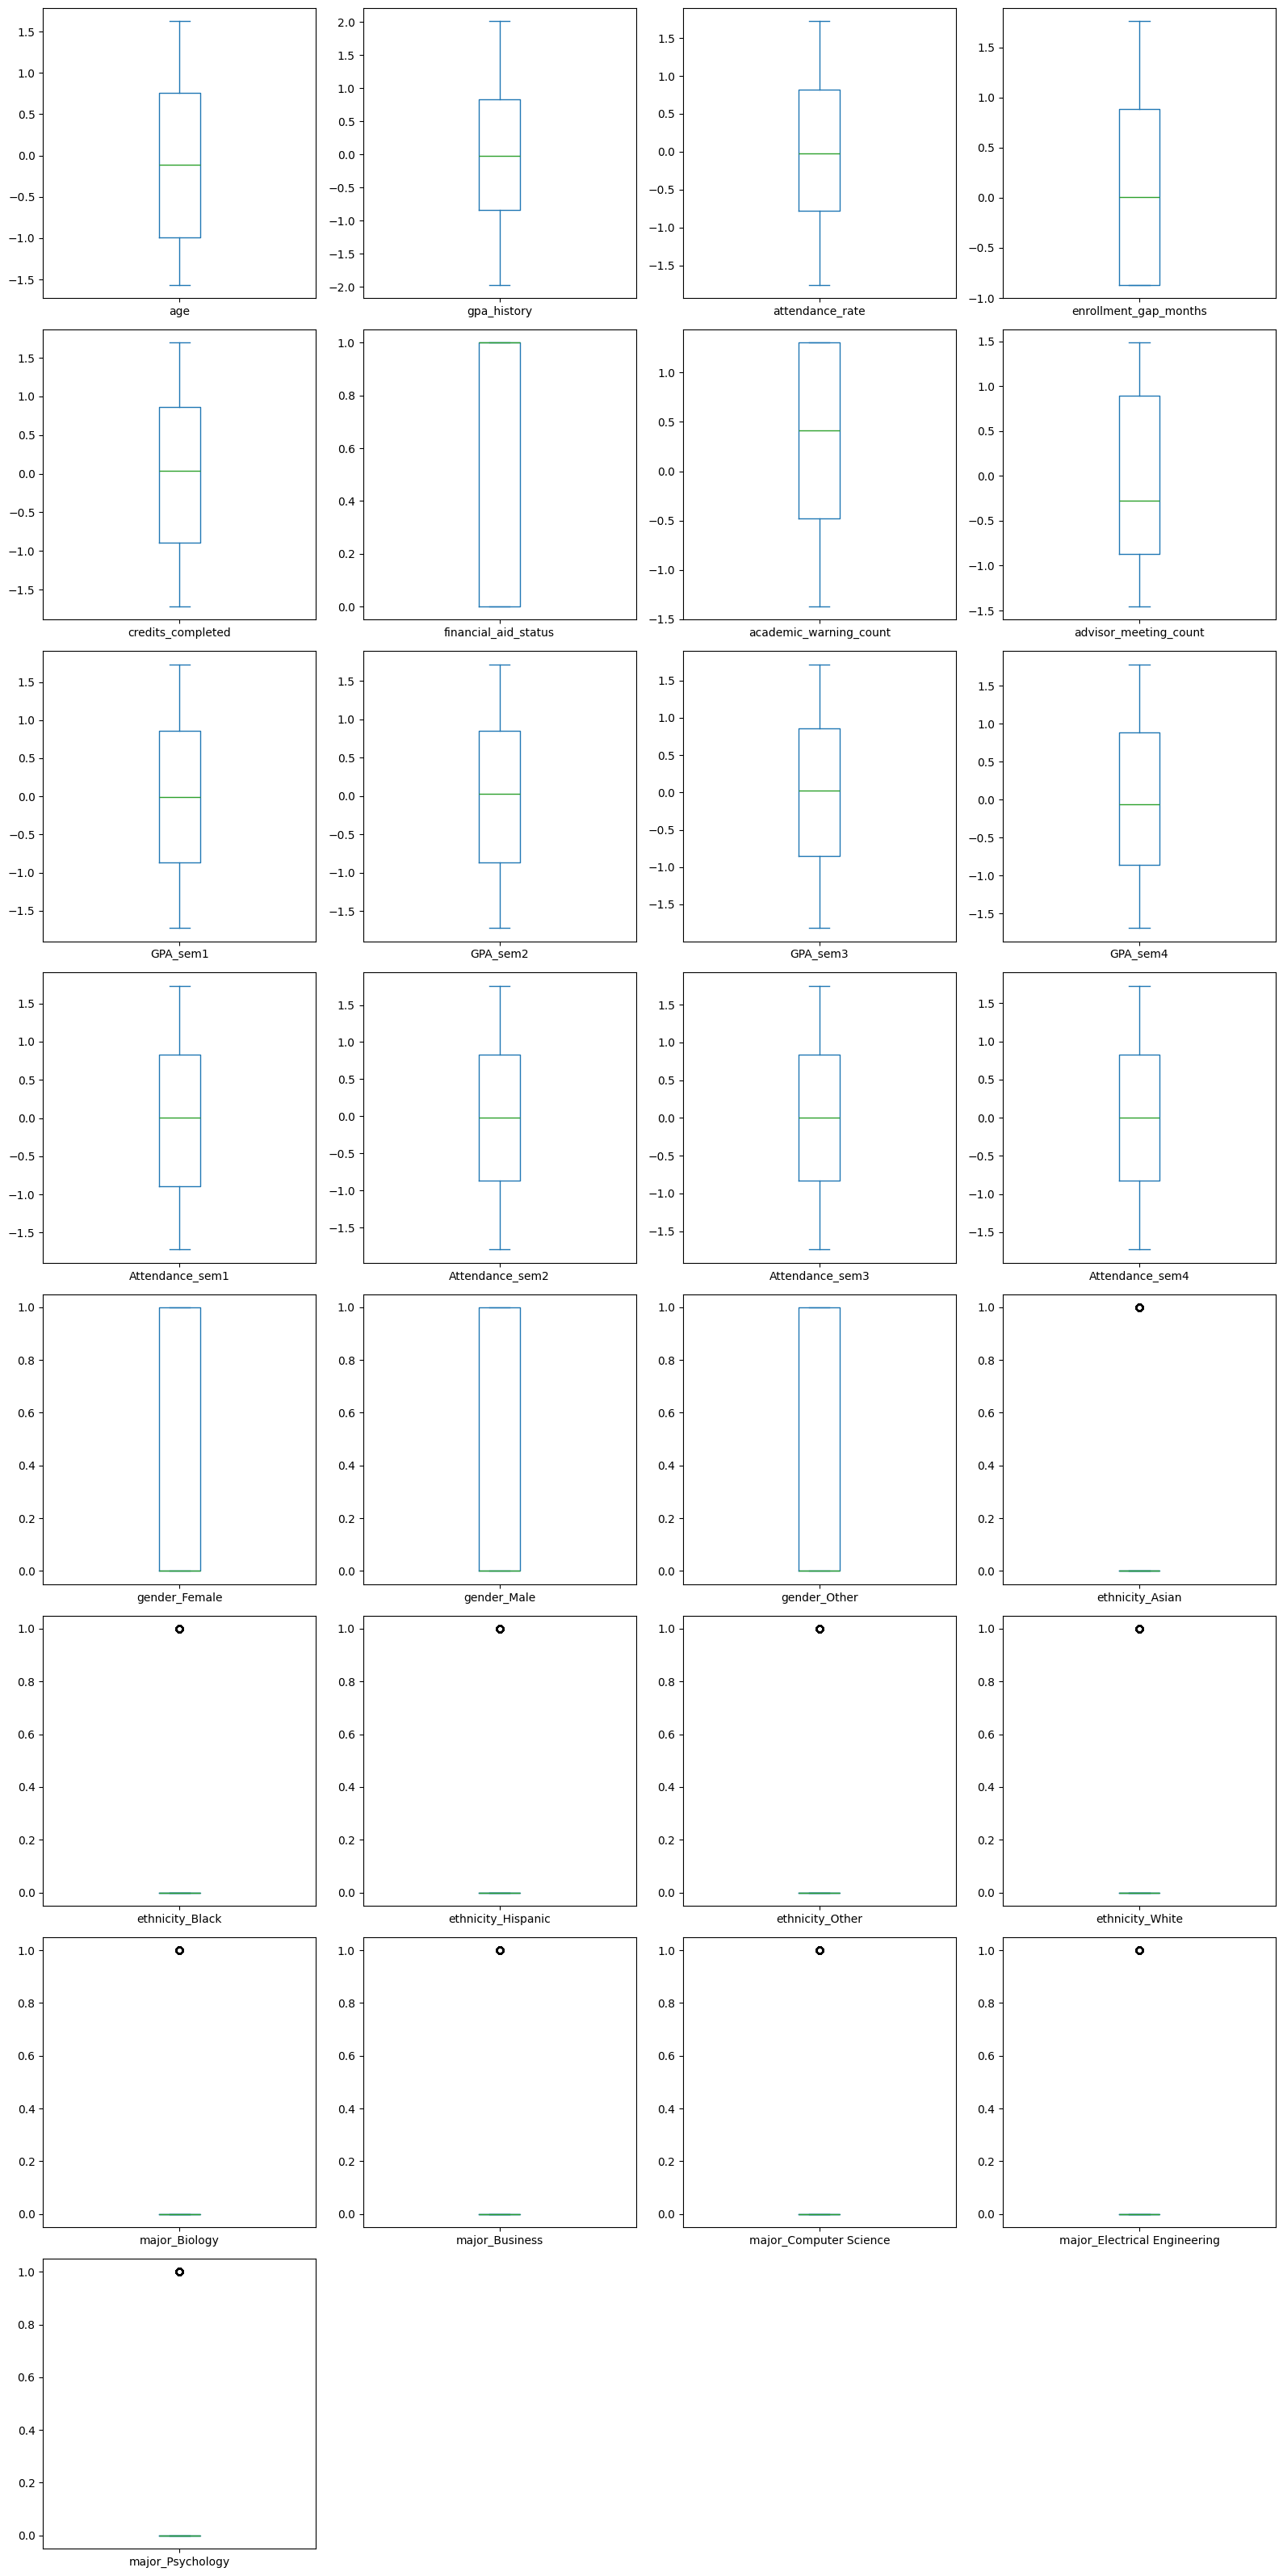

In [45]:
ncols = 4
nrows = int(np.ceil(df.shape[1] / ncols))

df.plot(kind='box', subplots=True, layout=(nrows, ncols), figsize=(16, 4*nrows), sharex=False, sharey=False)
plt.tight_layout()
plt.show()

# Klasterizacija

In [47]:
def evaluate_clustering(data, algorithm_class, k_range=range(2, 11), is_k_required=True, algo_name=None, **algorithm_params):
    inertia = []
    silhouette = []
    calinski = []
    davies = []
    cluster_counts = []

    if is_k_required:
        for k in k_range:
            model = algorithm_class(n_clusters=k, **algorithm_params)
            labels = model.fit_predict(data)

            cluster_counts.append(k)

            if hasattr(model, 'inertia_'):
                inertia.append(model.inertia_)
            else:
                inertia.append(np.nan)

            if len(set(labels)) > 1:
                silhouette.append(silhouette_score(data, labels))
                calinski.append(calinski_harabasz_score(data, labels))
                davies.append(davies_bouldin_score(data, labels))
            else:
                silhouette.append(np.nan)
                calinski.append(np.nan)
                davies.append(np.nan)
    else:
        model = algorithm_class(**algorithm_params)
        labels = model.fit_predict(data)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        cluster_counts.append(n_clusters)

        inertia.append(np.nan)  
        if len(set(labels)) > 1:
            silhouette.append(silhouette_score(data, labels))
            calinski.append(calinski_harabasz_score(data, labels))
            davies.append(davies_bouldin_score(data, labels))
        else:
            silhouette.append(np.nan)
            calinski.append(np.nan)
            davies.append(np.nan)

    title = algo_name or algorithm_class.__name__

    plt.figure(figsize=(14, 10))

    if any(not np.isnan(i) for i in inertia):
        plt.subplot(2, 2, 1)
        plt.plot(cluster_counts, inertia, marker='o')
        plt.title(f"{title} - Inertia")
        plt.xlabel("Broj klastera")
        plt.ylabel("Inercija")

    plt.subplot(2, 2, 2)
    plt.plot(cluster_counts, silhouette, marker='o')
    plt.title(f"{title} - Silhouette Score")
    plt.xlabel("Broj klastera")
    plt.ylabel("Silhouette")

    plt.subplot(2, 2, 3)
    plt.plot(cluster_counts, calinski, marker='o')
    plt.title(f"{title} - Calinski-Harabasz")
    plt.xlabel("Broj klastera")
    plt.ylabel("CH Score")

    plt.subplot(2, 2, 4)
    plt.plot(cluster_counts, davies, marker='o')
    plt.title(f"{title} - Davies-Bouldin")
    plt.xlabel("Broj klastera")
    plt.ylabel("DB Index")

    plt.tight_layout()
    plt.show()

In [48]:
def draw_umap_2d_3d(labels, df_clustered, random_state=42, n_neighbors=15, min_dist=0.1):
    labels = pd.Series(labels).reset_index(drop=True)
    df_clustered = df_clustered.reset_index(drop=True)
    labels_str = labels.astype(str)

    unique_clusters = sorted(labels_str.unique())
    n_clusters = len(unique_clusters)

    palette = sns.color_palette("hls", n_clusters)
    
    color_map = {cluster: palette[i] for i, cluster in enumerate(unique_clusters)}

    umap_2d = umap.UMAP(
        n_components=2,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        random_state=random_state
    )
    x_umap_2d = umap_2d.fit_transform(df_clustered)

    df_2d = pd.DataFrame(x_umap_2d, columns=["UMAP1", "UMAP2"])
    df_2d["Cluster"] = labels_str

    df_2d["Color"] = df_2d["Cluster"].map(color_map)

    plt.figure(figsize=(8, 6))
    plt.scatter(
        df_2d["UMAP1"], 
        df_2d["UMAP2"], 
        c=df_2d["Color"], 
        s=60, 
        alpha=0.8
    )
    plt.title("UMAP 2D prikaz klastera")
    plt.xlabel("UMAP1")
    plt.ylabel("UMAP2")

    for cluster, color in color_map.items():
        plt.scatter([], [], c=[color], label=cluster)
    plt.legend(title="Cluster")
    plt.show()
    
    # UMAP 3D embedding

    umap_3d = umap.UMAP(
        n_components=3,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        random_state=random_state
    )
    x_umap_3d = umap_3d.fit_transform(df_clustered)

    df_3d = pd.DataFrame(x_umap_3d, columns=["UMAP1", "UMAP2", "UMAP3"])
    df_3d["Cluster"] = labels_str

    df_3d["Color"] = df_3d["Cluster"].map(
        lambda c: "rgb({},{},{})".format(
            int(color_map[c][0]*255),
            int(color_map[c][1]*255),
            int(color_map[c][2]*255)
        )
    )

    fig = px.scatter_3d(
        df_3d,
        x="UMAP1",
        y="UMAP2",
        z="UMAP3",
        color="Cluster",
        color_discrete_map={cluster: df_3d[df_3d["Cluster"] == cluster]["Color"].iloc[0]
                            for cluster in unique_clusters},
        title="UMAP 3D prikaz klastera",
        opacity=0.8,
        height=700
    )

    fig.update_traces(marker=dict(size=5, opacity=0.85))
    fig.show()

In [49]:
def optimal_dendrogram(df, method='ward'):
    from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
    import numpy as np
    import matplotlib.pyplot as plt

    # Hijerarhijsko klasterovanje
    linked = linkage(df, method=method)
    distances = linked[:, 2]

    # Pronađi najveći "skok" u distancama
    diffs = np.diff(distances)
    max_jump_index = np.argmax(diffs)

    # Presek na mestu najvećeg skoka
    cut_off_distance = distances[max_jump_index]

    # Formiraj klastere
    clusters_found = fcluster(linked, cut_off_distance, criterion='distance')
    num_clusters = len(np.unique(clusters_found))

    # Plot dendrograma
    plt.figure(figsize=(12, 7))
    dendrogram(
        linked,
        color_threshold=cut_off_distance,
        distance_sort='descending'
    )

    plt.axhline(y=cut_off_distance, color='r', linestyle='--', linewidth=1.4,
                label=f'Presek (≈ {num_clusters} klastera)')
    plt.title(f"Dendrogram – optimalan broj klastera: {num_clusters}")
    plt.xlabel("Uzorci")
    plt.ylabel("Udaljenost")
    plt.legend()
    plt.show()

    return num_clusters

In [50]:
class DivisiveClustering(BaseEstimator, ClusterMixin):
    def __init__(self, n_clusters=2):
        self.n_clusters = n_clusters

    def fit(self, X, y=None):
        self.labels_ = self.divisive_clustering(X)
        return self

    def fit_predict(self, X, y=None):
        self.fit(X)
        return self.labels_

    def divisive_clustering(self, data):
        is_dataframe = isinstance(data, pd.DataFrame)
        data_size = len(data)

        clusters_to_divide = deque([(np.arange(data_size), data)])
        
        final_cluster_indices = []

        while len(final_cluster_indices) + len(clusters_to_divide) < self.n_clusters:
            if not clusters_to_divide:
                break 

            indices, subset = clusters_to_divide.popleft()
            
            if len(indices) <= 1:
                final_cluster_indices.append(indices)
                continue
                
            try:
                kmeans = KMeans(n_clusters=2, random_state=SEED, n_init='auto') 
                sub_labels = kmeans.fit_predict(subset)
            except ValueError:
                final_cluster_indices.append(indices)
                continue
            
            group0_indices = indices[sub_labels == 0]
            group1_indices = indices[sub_labels == 1]
            
            if is_dataframe:
                subset0 = data.iloc[group0_indices]
                subset1 = data.iloc[group1_indices]
            else:
                subset0 = data[group0_indices]
                subset1 = data[group1_indices]

            clusters_to_divide.append((group0_indices, subset0))
            clusters_to_divide.append((group1_indices, subset1))
        
        all_clusters_indices = list(clusters_to_divide) + [(idx, None) for idx, _ in final_cluster_indices]
        
        labels = np.full(data_size, -1)
        
        for i in range(self.n_clusters):
            if i < len(all_clusters_indices):
                indices = all_clusters_indices[i][0]
                labels[indices] = i
            else:
                break
        
        labels[labels == -1] = self.n_clusters - 1
        
        return labels

In [51]:
def evaluate_dbscan(X, eps_values=None, min_samples_values=None):
    
    if eps_values is None:
        eps_values = np.linspace(0.1, 2.0, 20)
    if min_samples_values is None:
        min_samples_values = range(2, 10)

    results = []
    labels_dict = {}

    for eps in eps_values:
        for min_s in min_samples_values:
            db = DBSCAN(eps=eps, min_samples=min_s)
            labels = db.fit_predict(X)
            labels_dict[(eps, min_s)] = labels

            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

            if n_clusters == 0:
                results.append((eps, min_s, np.nan, np.nan, np.nan, 0))
                continue

            sil = silhouette_score(X, labels) if n_clusters > 1 else np.nan
            cal = calinski_harabasz_score(X, labels) if n_clusters > 1 else np.nan
            dav = davies_bouldin_score(X, labels) if n_clusters > 1 else np.nan

            results.append((eps, min_s, sil, cal, dav, n_clusters))

    results = np.array(results, dtype=object)

    fig, axes = plt.subplots(1, 4, figsize=(24, 5))

    metrics = ['Silhouette', 'Calinski-Harabasz', 'Davies-Bouldin', 'Num Clusters']
    for i, metric in enumerate(metrics):
        ax = axes[i]
        metric_values = results[:, 2 + i].astype(float)

        heatmap = metric_values.reshape(len(eps_values), len(min_samples_values))
        im = ax.imshow(heatmap, origin='lower', aspect='auto',
                       extent=[min(min_samples_values), max(min_samples_values),
                               min(eps_values), max(eps_values)],
                       cmap='viridis')

        ax.set_title(metric)
        ax.set_xlabel("min_samples")
        ax.set_ylabel("eps")
        fig.colorbar(im, ax=ax)

    plt.tight_layout()
    plt.show()

    valid_rows = ~np.isnan(results[:, 2].astype(float))
    valid_results = results[valid_rows]

    if valid_results.size > 0:
        best_sil = valid_results[np.nanargmax(valid_results[:, 2].astype(float))]
        best_cal = valid_results[np.nanargmax(valid_results[:, 3].astype(float))]
        best_dav = valid_results[np.nanargmin(valid_results[:, 4].astype(float))]

        print("\nNajbolji parametri po metrikama:")
        print(f"Silhouette: eps={best_sil[0]:.3f}, min_samples={best_sil[1]}, "
              f"score={best_sil[2]:.3f}, n_clusters={int(best_sil[5])}")
        print(f"Calinski-Harabasz: eps={best_cal[0]:.3f}, min_samples={best_cal[1]}, "
              f"score={best_cal[3]:.3f}, n_clusters={int(best_cal[5])}")
        print(f"Davies-Bouldin: eps={best_dav[0]:.3f}, min_samples={best_dav[1]}, "
              f"score={best_dav[4]:.3f}, n_clusters={int(best_dav[5])}")
    else:
        print("Nema validnih klastera za prikazane parametre.")

In [52]:
def evaluate_hdbscan(X, min_cluster_values=None, min_samples_values=None):
    if min_cluster_values is None:
        min_cluster_values = range(5, 50, 5)
    if min_samples_values is None:
        min_samples_values = range(2, 20, 2)

    results = []
    labels_dict = {}

    for min_cluster in min_cluster_values:
        for min_s in min_samples_values:
            clusterer = hdbscan.HDBSCAN(min_samples=min_s, min_cluster_size=min_cluster)
            labels = clusterer.fit_predict(X)
            labels_dict[(min_cluster, min_s)] = labels

            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

            if n_clusters == 0:
                results.append((min_cluster, min_s, np.nan, np.nan, np.nan, 0))
                continue

            sil = silhouette_score(X, labels) if n_clusters > 1 else np.nan
            cal = calinski_harabasz_score(X, labels) if n_clusters > 1 else np.nan
            dav = davies_bouldin_score(X, labels) if n_clusters > 1 else np.nan

            results.append((min_cluster, min_s, sil, cal, dav, n_clusters))

    results = np.array(results, dtype=object)

    fig, axes = plt.subplots(1, 4, figsize=(24, 5))
    metrics = ['Silhouette', 'Calinski-Harabasz', 'Davies-Bouldin', 'Num Clusters']

    for i, metric in enumerate(metrics):
        ax = axes[i]
        metric_values = results[:, 2 + i].astype(float)
        heatmap = metric_values.reshape(len(min_cluster_values), len(min_samples_values))

        im = ax.imshow(heatmap, origin='lower', aspect='auto',
                       extent=[min(min_samples_values), max(min_samples_values),
                               min(min_cluster_values), max(min_cluster_values)],
                       cmap='viridis')

        ax.set_title(metric)
        ax.set_xlabel("min_samples")
        ax.set_ylabel("min_cluster_size")
        fig.colorbar(im, ax=ax)

    plt.tight_layout()
    plt.show()

    valid_rows = ~np.isnan(results[:, 2].astype(float))
    valid_results = results[valid_rows]

    if valid_results.size > 0:
        best_sil = valid_results[np.nanargmax(valid_results[:, 2].astype(float))]
        best_cal = valid_results[np.nanargmax(valid_results[:, 3].astype(float))]
        best_dav = valid_results[np.nanargmin(valid_results[:, 4].astype(float))]

        print("\nNajbolji parametri po metriki:")
        print(f"Silhouette: min_cluster_size={best_sil[0]}, min_samples={best_sil[1]}, "
              f"score={best_sil[2]:.3f}, n_clusters={int(best_sil[5])}")
        print(f"Calinski-Harabasz: min_cluster_size={best_cal[0]}, min_samples={best_cal[1]}, "
              f"score={best_cal[3]:.3f}, n_clusters={int(best_cal[5])}")
        print(f"Davies-Bouldin: min_cluster_size={best_dav[0]}, min_samples={best_dav[1]}, "
              f"score={best_dav[4]:.3f}, n_clusters={int(best_dav[5])}")
    else:
        print("Nema validnih klastera za prikazane parametre.")

In [53]:
def plot_discrete_histograms_grouped(df_scaled, df_original, cluster_col, numeric_col, title=None):

    df_hist = df_scaled.copy()
    df_hist[numeric_col] = df_original[numeric_col].astype(int)

    clusters = sorted(df_hist[cluster_col].unique())
    n_clusters = len(clusters)

    values = np.sort(df_hist[numeric_col].unique())
    if -1 in values:
        values = np.insert(values, 0, -1)

    total_width = 0.8
    width = total_width / n_clusters

    plt.figure(figsize=(6, 4))

    for i, cluster in enumerate(clusters):
        subset = df_hist[df_hist[cluster_col] == cluster][numeric_col]
        counts = subset.value_counts().reindex(values, fill_value=0)

        plt.bar(values + i*width - total_width/2 + width/2, counts, width=width, label=f'Cluster {cluster}')

    plt.xlabel(numeric_col)
    plt.ylabel("Count")
    plt.title(title if title else f"Distribucija {numeric_col} po klasterima")
    plt.xticks(values)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [246]:
def plot_cluster_heatmap(df, cluster_col, target_col, cmap="Blues"):
    dist = pd.crosstab(df[cluster_col], df[target_col], normalize='index') * 100
    
    plt.figure(figsize=(8, 5))
    sns.heatmap(dist, annot=True, cmap=cmap, fmt=".1f")
    plt.title(f"Distribucija '{target_col}' po klasterima (%)")
    plt.ylabel(cluster_col)
    plt.xlabel(target_col)
    plt.show()

In [54]:
df.columns

Index(['age', 'gpa_history', 'attendance_rate', 'enrollment_gap_months',
       'credits_completed', 'financial_aid_status', 'academic_warning_count',
       'advisor_meeting_count', 'GPA_sem1', 'GPA_sem2', 'GPA_sem3', 'GPA_sem4',
       'Attendance_sem1', 'Attendance_sem2', 'Attendance_sem3',
       'Attendance_sem4', 'gender_Female', 'gender_Male', 'gender_Other',
       'ethnicity_Asian', 'ethnicity_Black', 'ethnicity_Hispanic',
       'ethnicity_Other', 'ethnicity_White', 'major_Biology', 'major_Business',
       'major_Computer Science', 'major_Electrical Engineering',
       'major_Psychology'],
      dtype='object')

## Centroidi

### KMeans

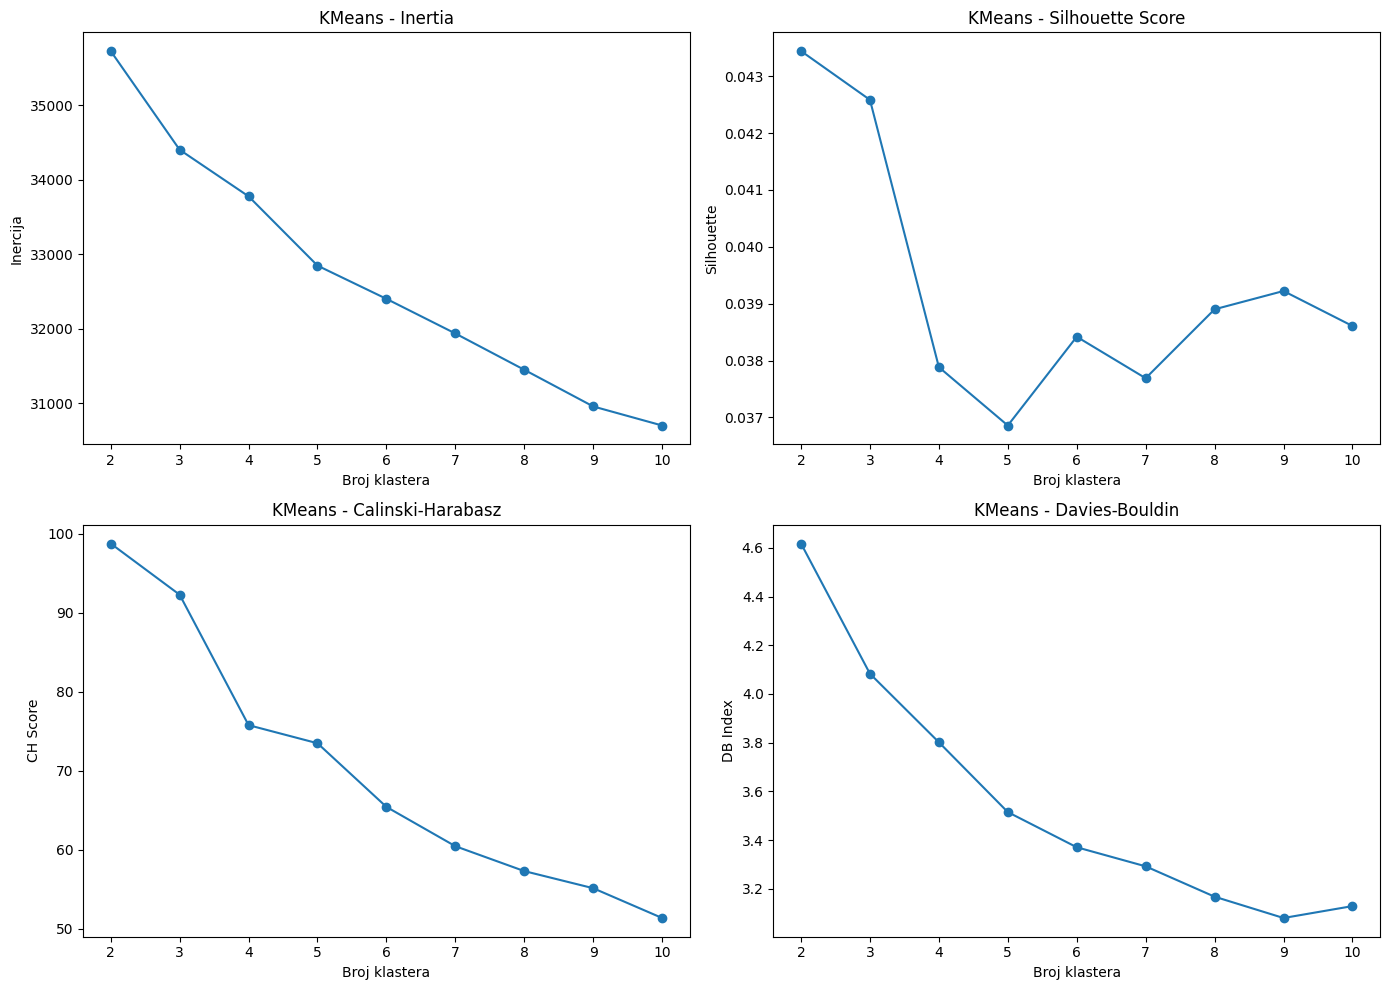

In [57]:
evaluate_clustering(data=df, algorithm_class=KMeans, k_range=range(2, 11), is_k_required=True, algo_name="KMeans", random_state=SEED, n_init='auto')

In [248]:
k =3

kmeans = KMeans(n_clusters=k, random_state=SEED, n_init='auto')
cluster_labels = kmeans.fit_predict(df)

df_KMeans = df.copy()
df_KMeans['Cluster'] = cluster_labels

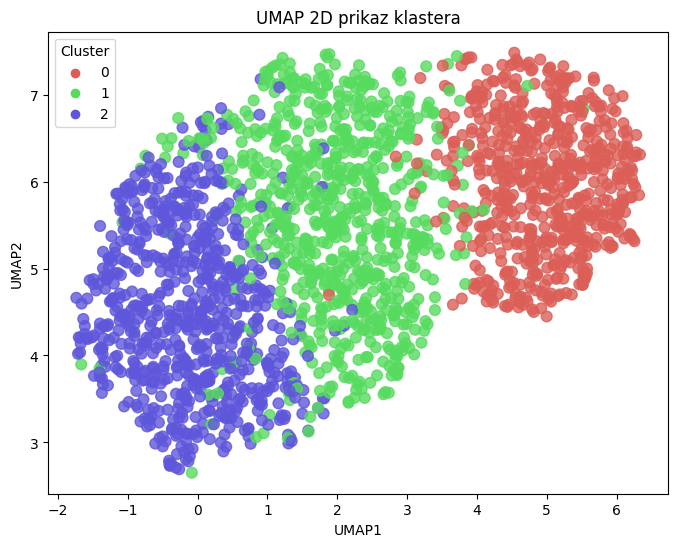

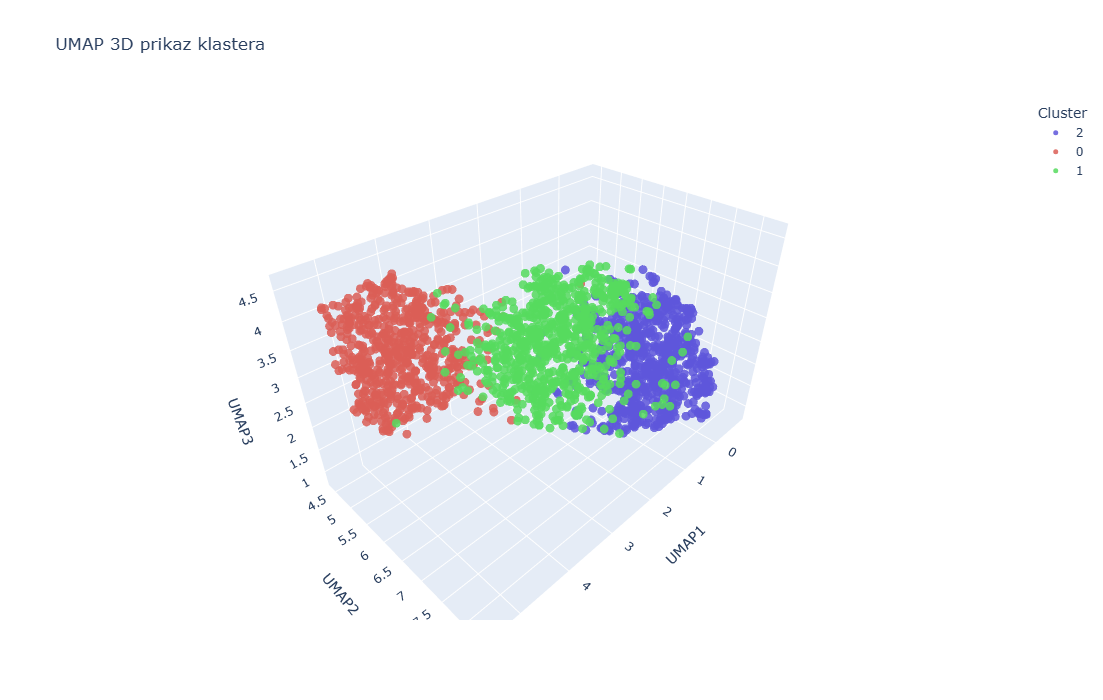

In [196]:
draw_umap_2d_3d(cluster_labels, df_KMeans)

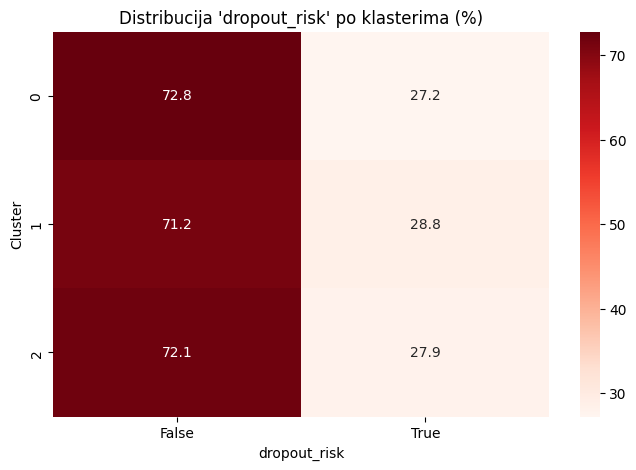

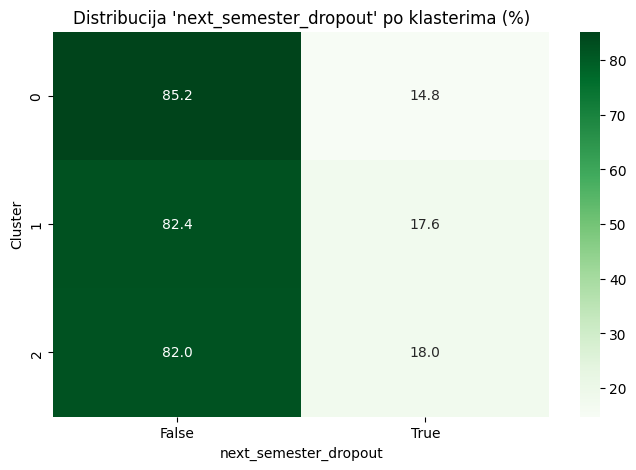

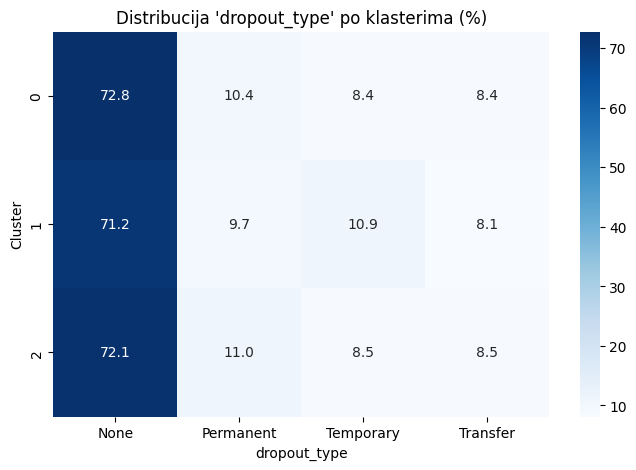

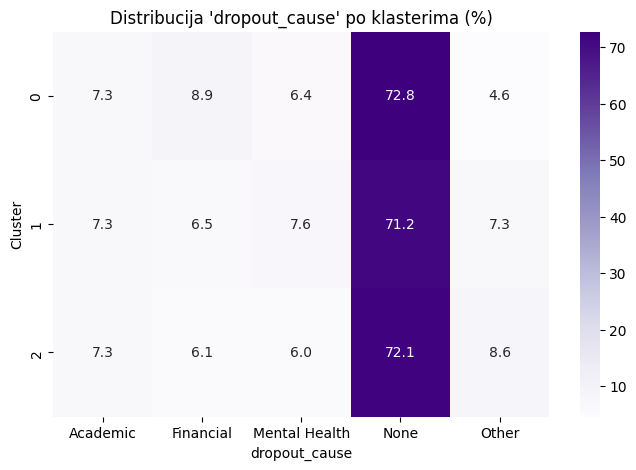

In [252]:
df_clustered = df_imputed.copy()
df_clustered['Cluster'] = cluster_labels

plot_cluster_heatmap(df_clustered, "Cluster", "dropout_risk", cmap="Reds")
plot_cluster_heatmap(df_clustered, "Cluster", "next_semester_dropout", cmap="Greens")
plot_cluster_heatmap(df_clustered, "Cluster", "dropout_type")
plot_cluster_heatmap(df_clustered, "Cluster", "dropout_cause", cmap="Purples")

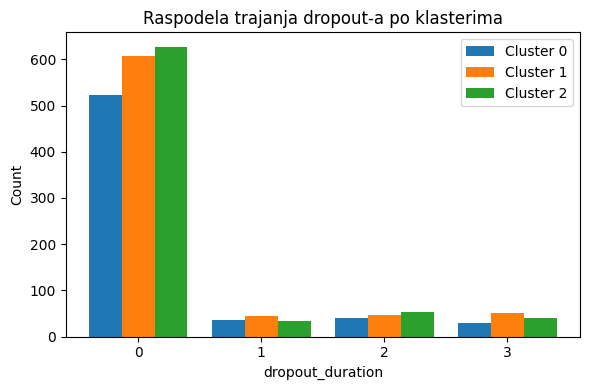

In [254]:
plot_discrete_histograms_grouped(
    df_scaled=df_KMeans,
    df_original=df_original,
    cluster_col='Cluster',
    numeric_col='dropout_duration',
    title='Raspodela trajanja dropout-a po klasterima'
)

## Hijerarhijski algoritmi

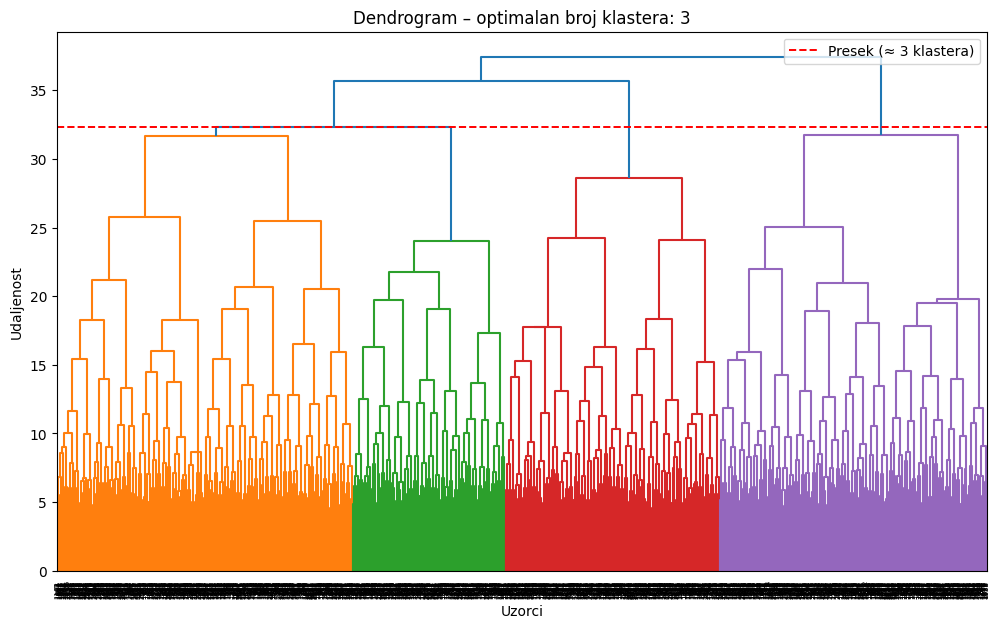

Optimalan broj klastera: 3


In [62]:
optimal = optimal_dendrogram(df.copy())
print(f"Optimalan broj klastera: {optimal}")

### Aglomerativno

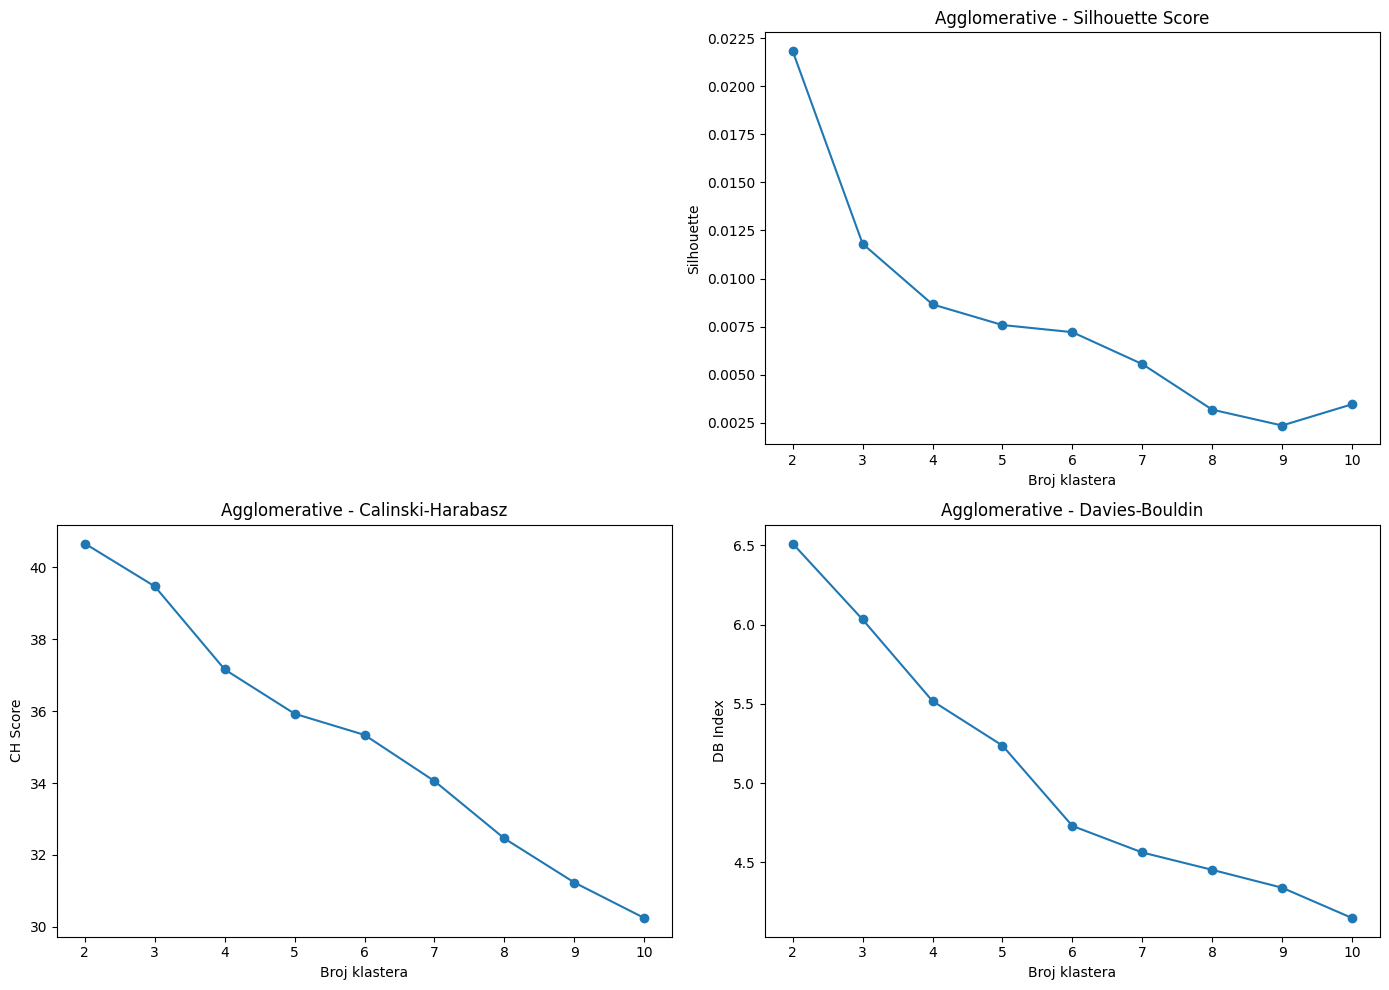

In [64]:
evaluate_clustering(data=df, algorithm_class=AgglomerativeClustering, k_range=range(2, 11), is_k_required=True, algo_name="Agglomerative", linkage='ward')

In [256]:
k = 3

model_dend = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward')
cluster_labels = model_dend.fit_predict(df)

df_Agglomerative_dend=df.copy()
df_Agglomerative_dend['Cluster'] = cluster_labels

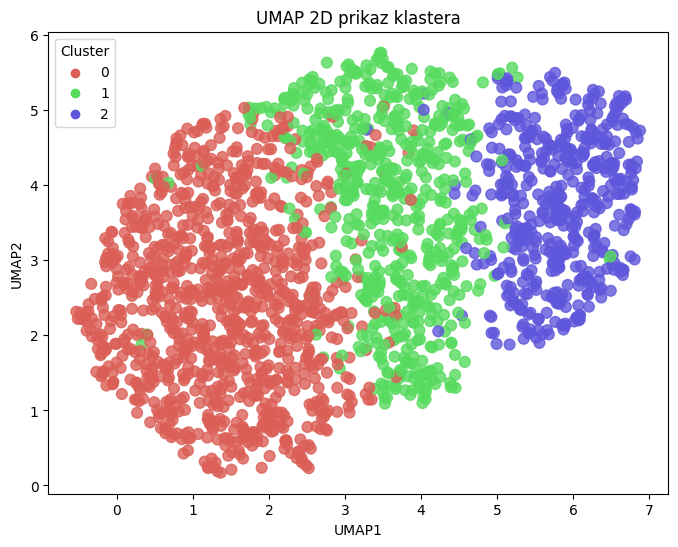

In [66]:
draw_umap_2d_3d(cluster_labels, df_Agglomerative_dend)

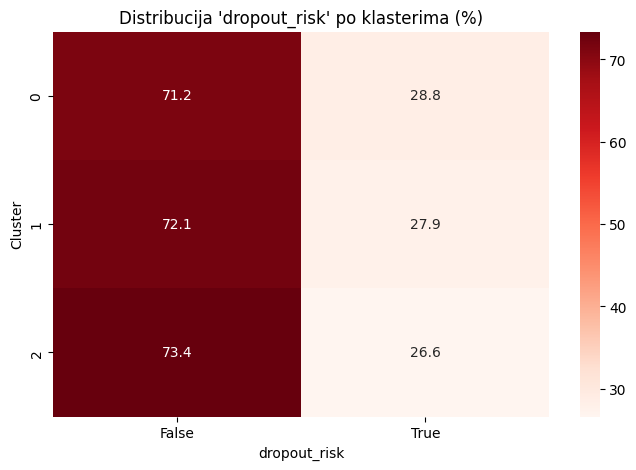

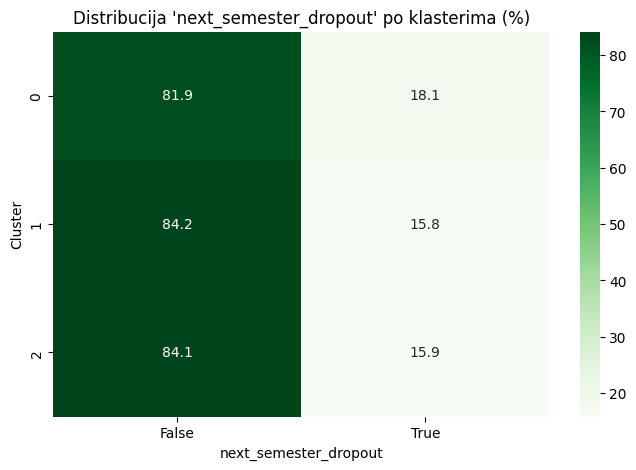

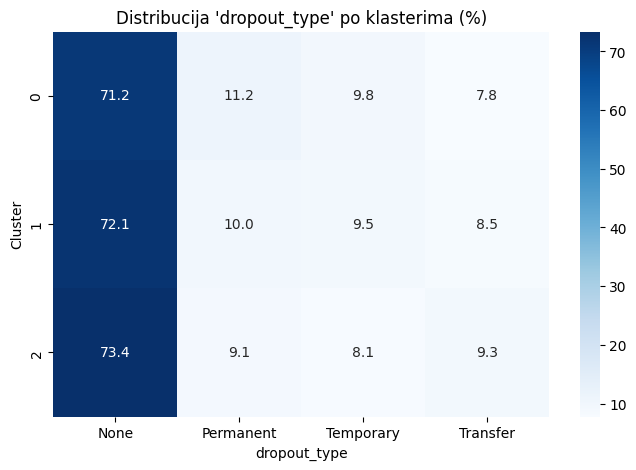

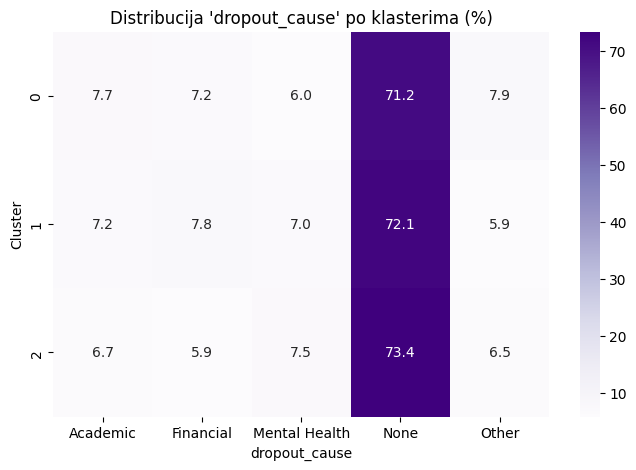

In [258]:
df_clustered = df_imputed.copy()
df_clustered['Cluster'] = cluster_labels

plot_cluster_heatmap(df_clustered, "Cluster", "dropout_risk", cmap="Reds")
plot_cluster_heatmap(df_clustered, "Cluster", "next_semester_dropout", cmap="Greens")
plot_cluster_heatmap(df_clustered, "Cluster", "dropout_type")
plot_cluster_heatmap(df_clustered, "Cluster", "dropout_cause", cmap="Purples")

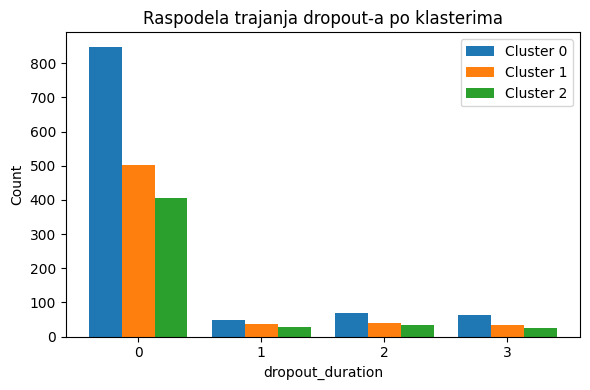

In [260]:
plot_discrete_histograms_grouped(
    df_scaled=df_Agglomerative_dend,
    df_original=df_original,
    cluster_col='Cluster',
    numeric_col='dropout_duration',
    title='Raspodela trajanja dropout-a po klasterima'
)

### Divisive

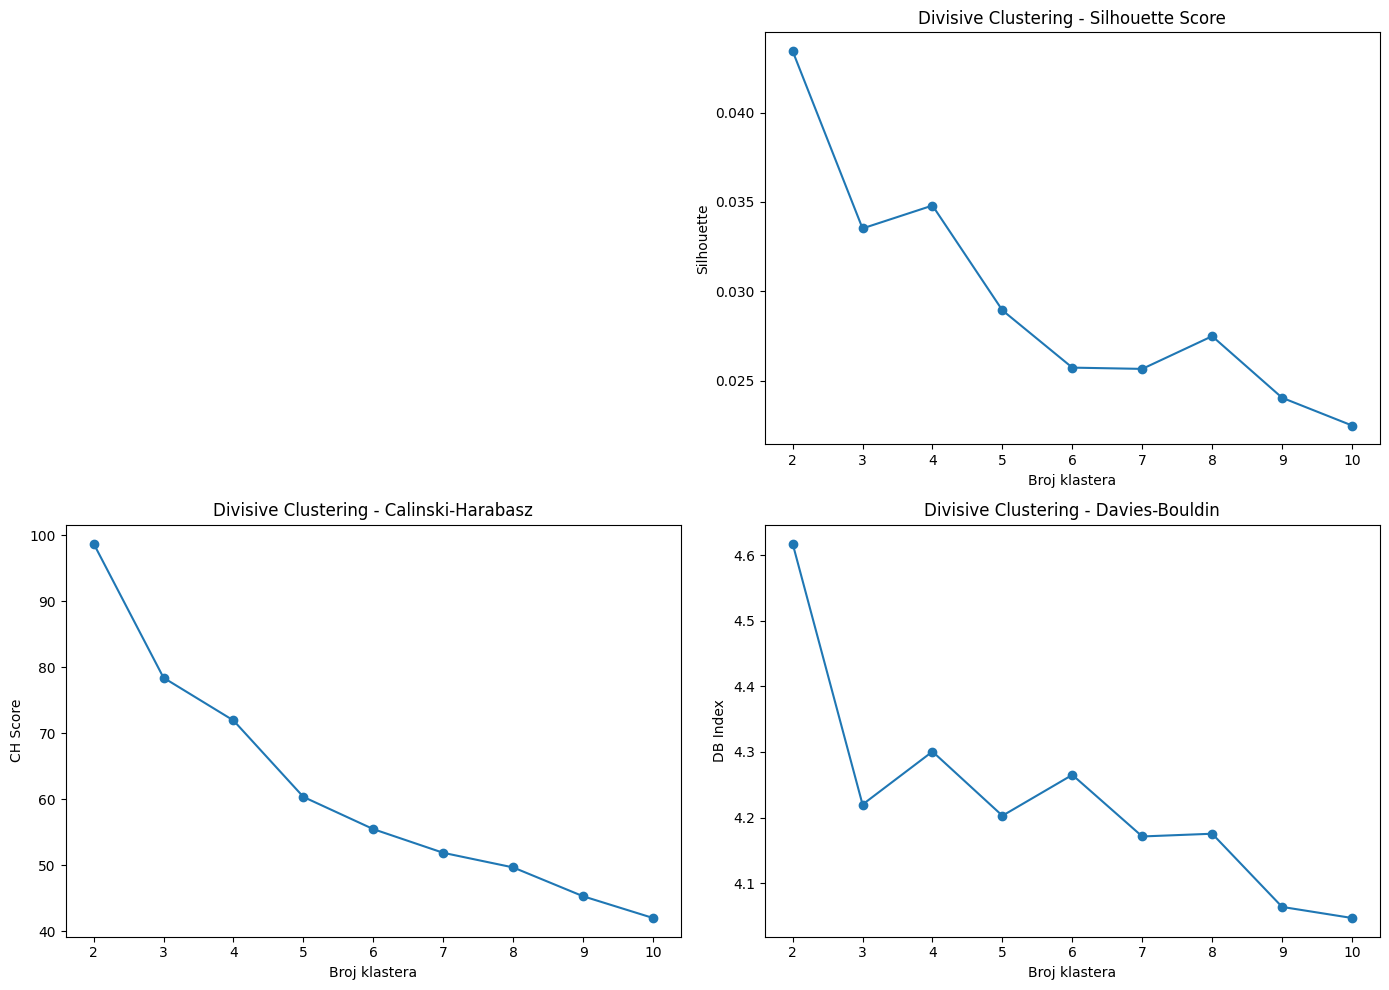

In [69]:
evaluate_clustering(data=df, algorithm_class=DivisiveClustering, k_range=range(2, 11), is_k_required=True, algo_name='Divisive Clustering')

In [262]:
k=3

model_dend = DivisiveClustering(n_clusters=k)
cluster_labels = model_dend.fit_predict(df)

df_Divisive_dend = df.copy()
df_Divisive_dend['Cluster'] = cluster_labels

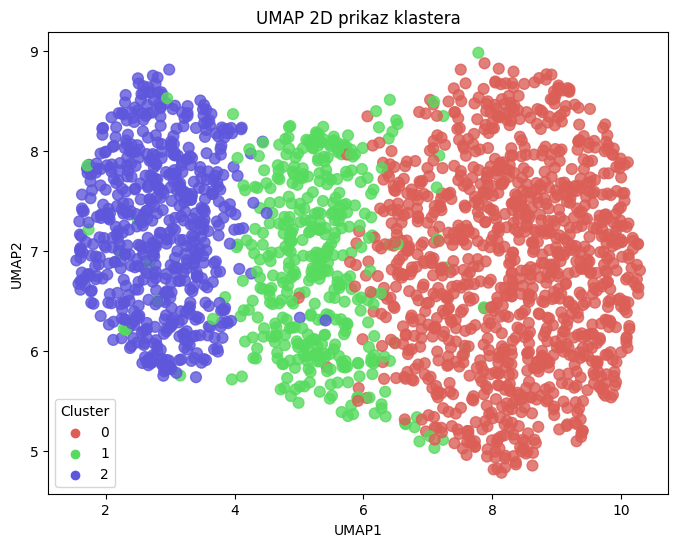

In [71]:
draw_umap_2d_3d(cluster_labels, df_Divisive_dend)

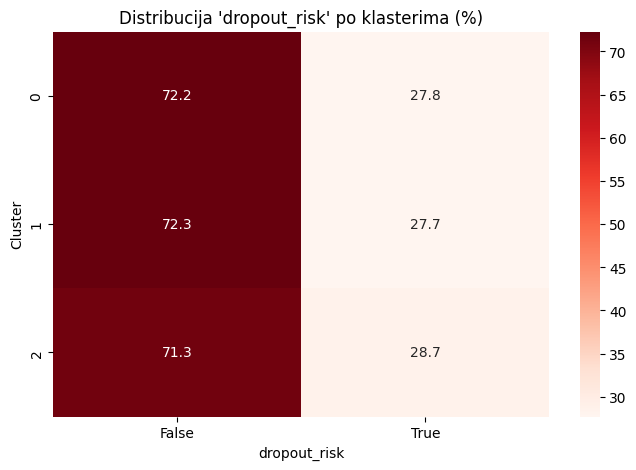

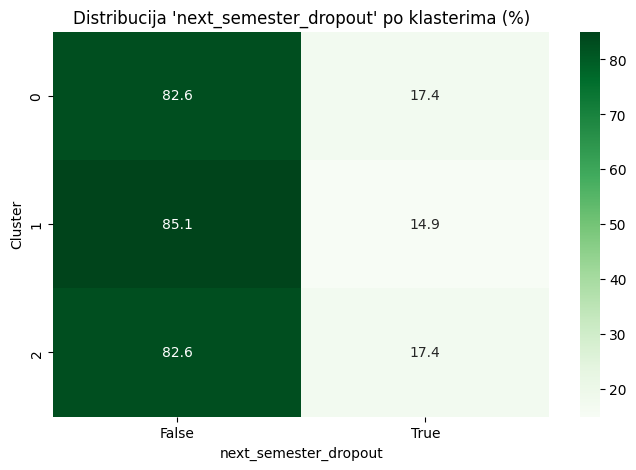

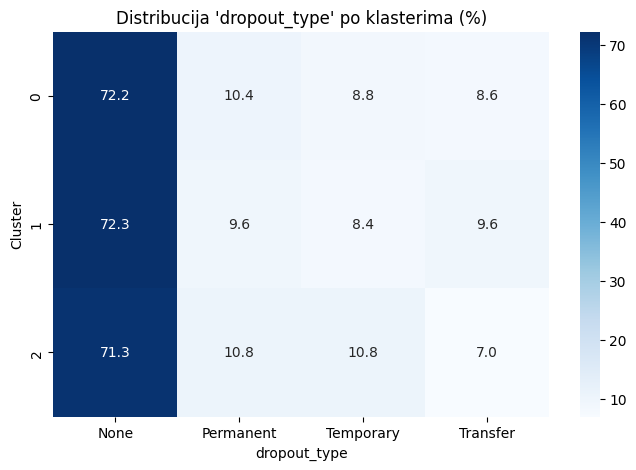

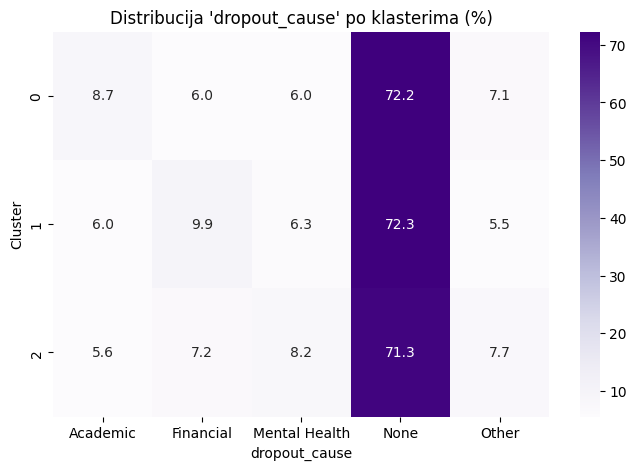

In [264]:
df_clustered = df_imputed.copy()
df_clustered['Cluster'] = cluster_labels

plot_cluster_heatmap(df_clustered, "Cluster", "dropout_risk", cmap="Reds")
plot_cluster_heatmap(df_clustered, "Cluster", "next_semester_dropout", cmap="Greens")
plot_cluster_heatmap(df_clustered, "Cluster", "dropout_type")
plot_cluster_heatmap(df_clustered, "Cluster", "dropout_cause", cmap="Purples")

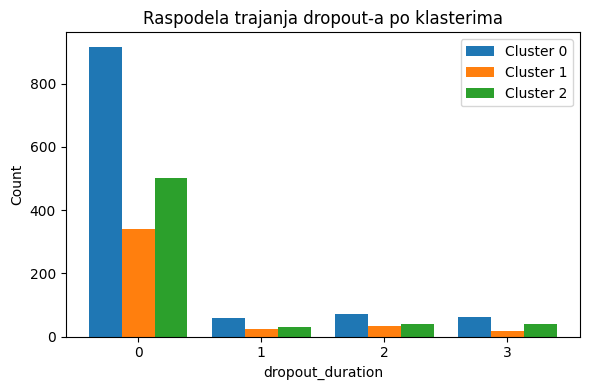

In [266]:
plot_discrete_histograms_grouped(
    df_scaled=df_Divisive_dend,
    df_original=df_original,
    cluster_col='Cluster',
    numeric_col='dropout_duration',
    title='Raspodela trajanja dropout-a po klasterima'
)

## Gustinski algoritmi

### DBSCAN

In [75]:
X = df.values

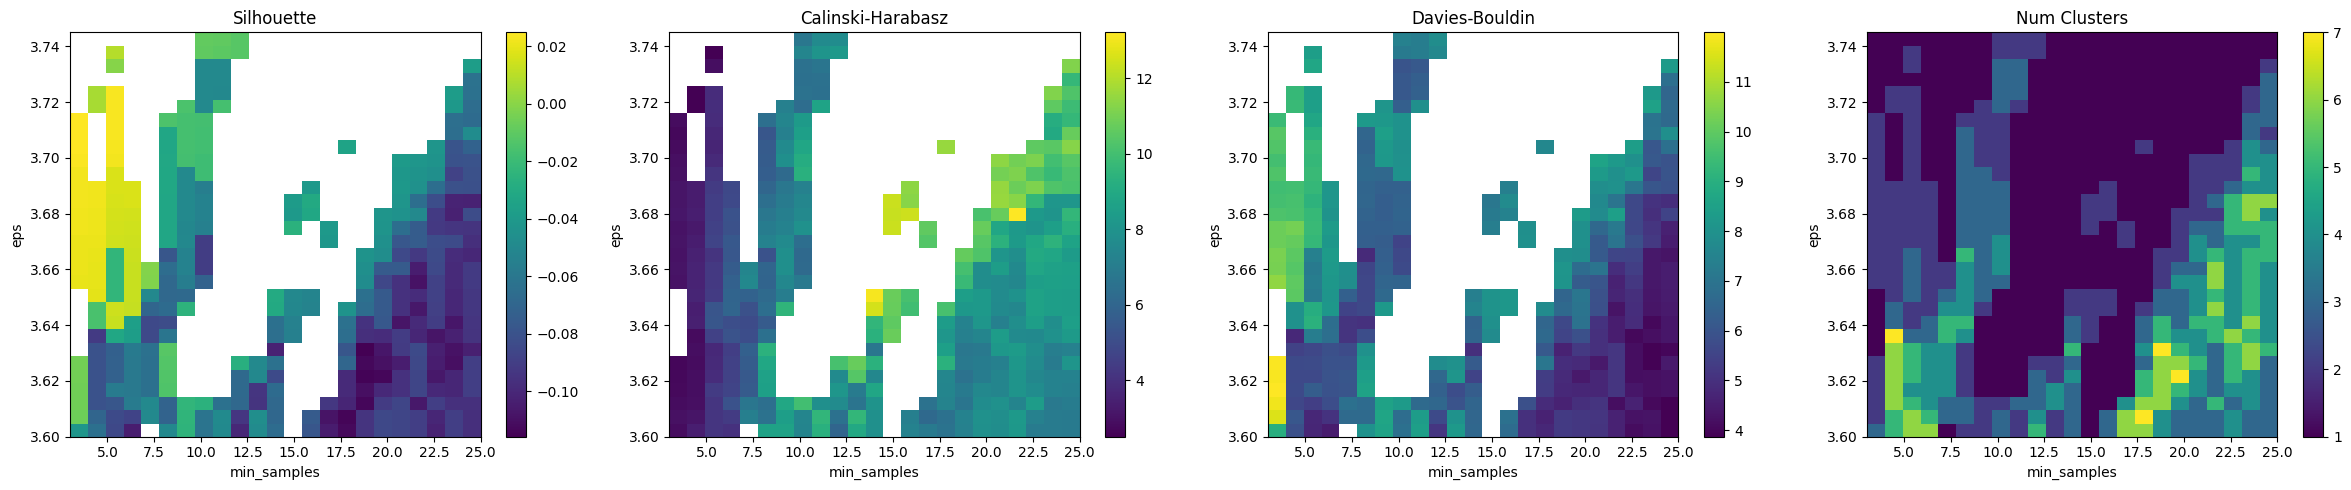


Najbolji parametri po metrikama:
Silhouette: eps=3.715, min_samples=3, score=0.025, n_clusters=2
Calinski-Harabasz: eps=3.680, min_samples=22, score=13.210, n_clusters=2
Davies-Bouldin: eps=3.600, min_samples=25, score=3.871, n_clusters=3


In [76]:
evaluate_dbscan(X, eps_values=np.arange(3.6, 3.75, 0.005), min_samples_values=range(3, 26, 1))

In [268]:
dbscan_sil = DBSCAN(eps=3.715, min_samples=3)
cluster_labels = dbscan_sil.fit_predict(df)

df_DBSCAN = df.copy()
df_DBSCAN['Cluster'] = cluster_labels

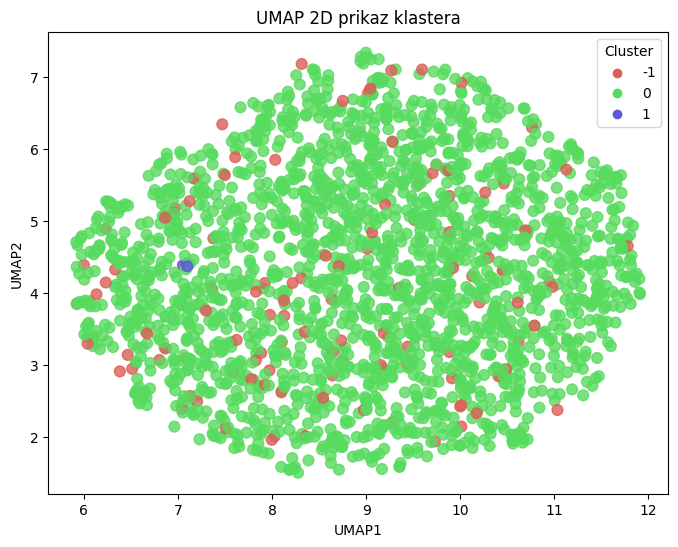

In [78]:
draw_umap_2d_3d(cluster_labels, df_DBSCAN)

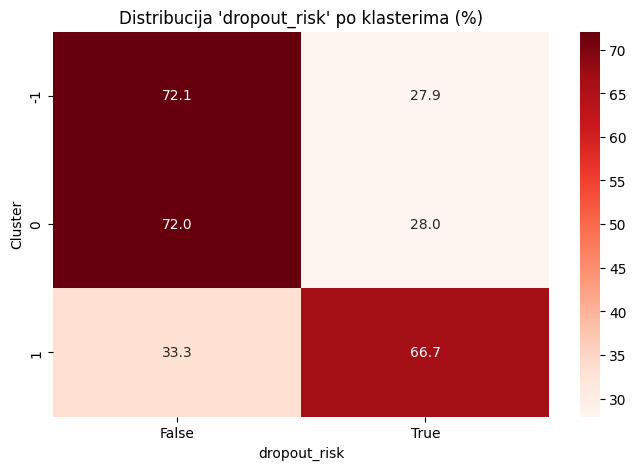

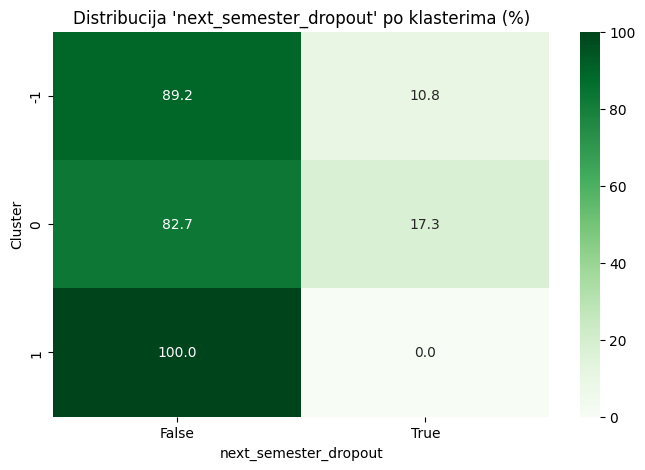

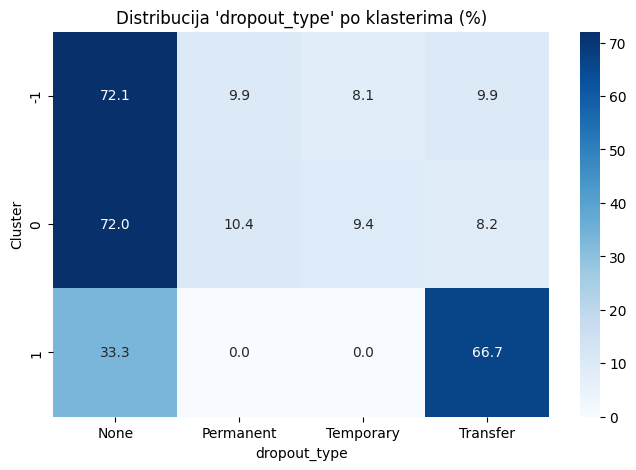

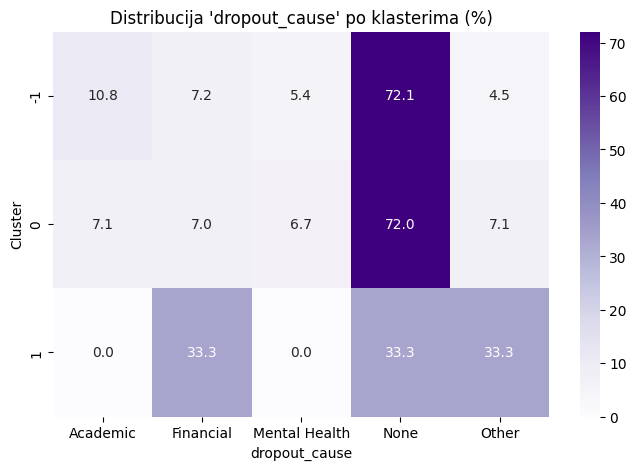

In [270]:
df_clustered = df_imputed.copy()
df_clustered['Cluster'] = cluster_labels

plot_cluster_heatmap(df_clustered, "Cluster", "dropout_risk", cmap="Reds")
plot_cluster_heatmap(df_clustered, "Cluster", "next_semester_dropout", cmap="Greens")
plot_cluster_heatmap(df_clustered, "Cluster", "dropout_type")
plot_cluster_heatmap(df_clustered, "Cluster", "dropout_cause", cmap="Purples")

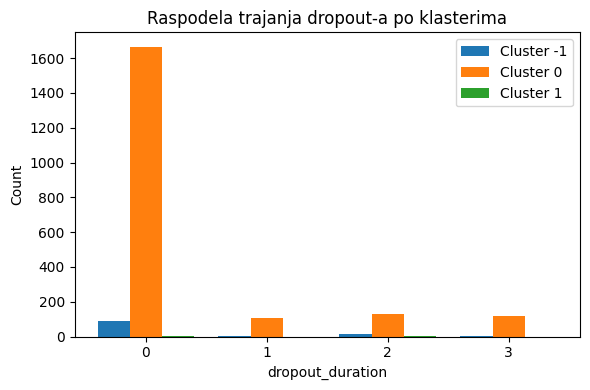

In [272]:
plot_discrete_histograms_grouped(
    df_scaled=df_DBSCAN,
    df_original=df_original,
    cluster_col='Cluster',
    numeric_col='dropout_duration',
    title='Raspodela trajanja dropout-a po klasterima'
)

### HDBSCAN

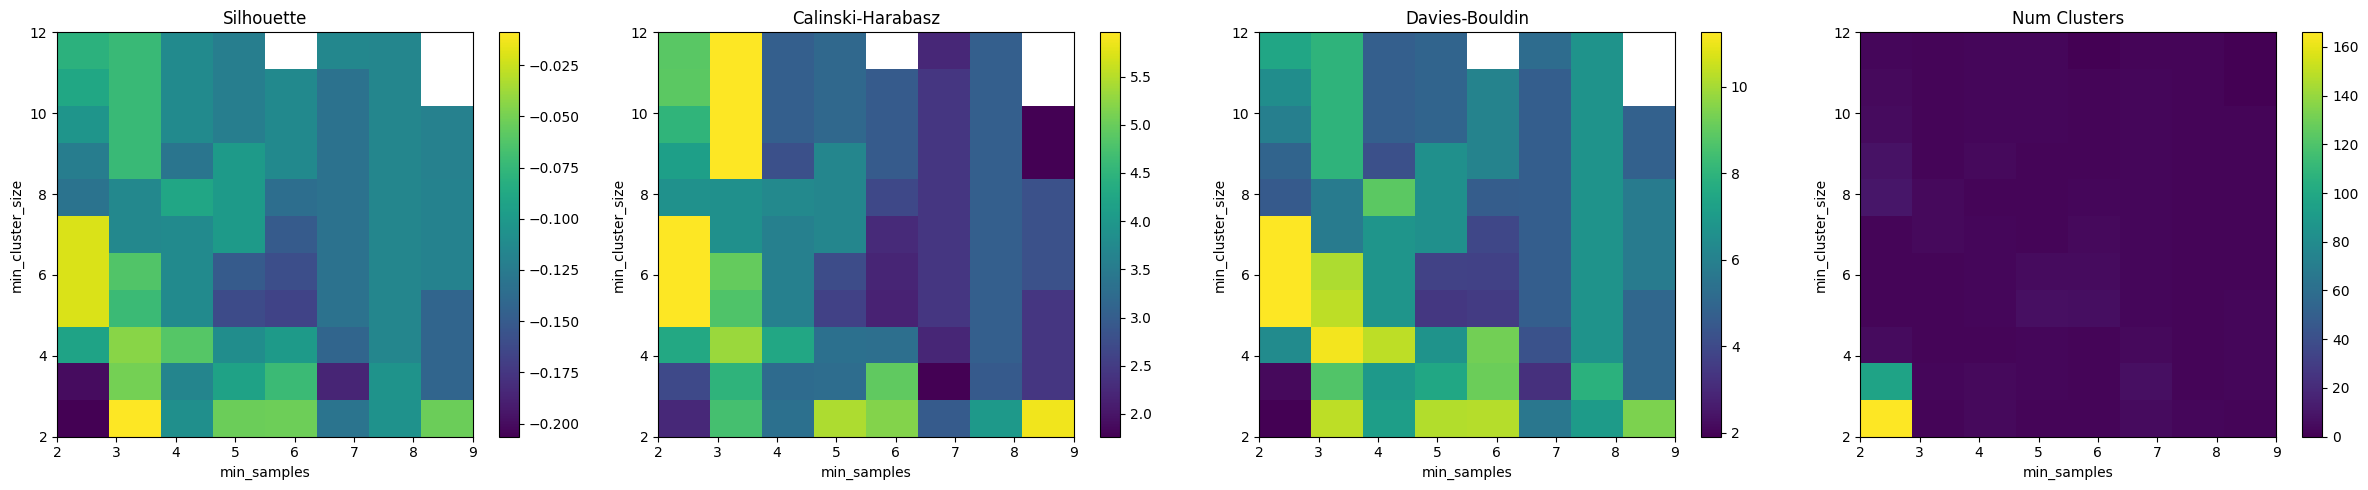


Najbolji parametri po metriki:
Silhouette: min_cluster_size=2, min_samples=3, score=-0.009, n_clusters=2
Calinski-Harabasz: min_cluster_size=9, min_samples=3, score=5.959, n_clusters=2
Davies-Bouldin: min_cluster_size=2, min_samples=2, score=1.908, n_clusters=166


In [81]:
min_cluster_values = range(2, 13, 1)#[5, 10, 15, 20]
min_samples_values = range(2, 10, 1)#[2, 5, 10]

evaluate_hdbscan(X, min_cluster_values=min_cluster_values, min_samples_values=min_samples_values)

In [274]:
clusterer = hdbscan.HDBSCAN(min_samples=3, min_cluster_size=2)
cluster_labels = clusterer.fit_predict(X)

In [276]:
df_HDBSCAN = df.copy()
df_HDBSCAN['Cluster'] = cluster_labels

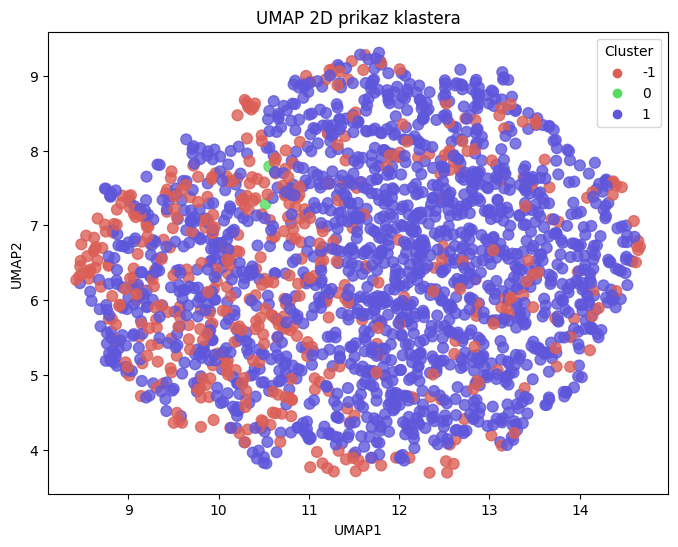

In [84]:
draw_umap_2d_3d(cluster_labels, df_HDBSCAN)

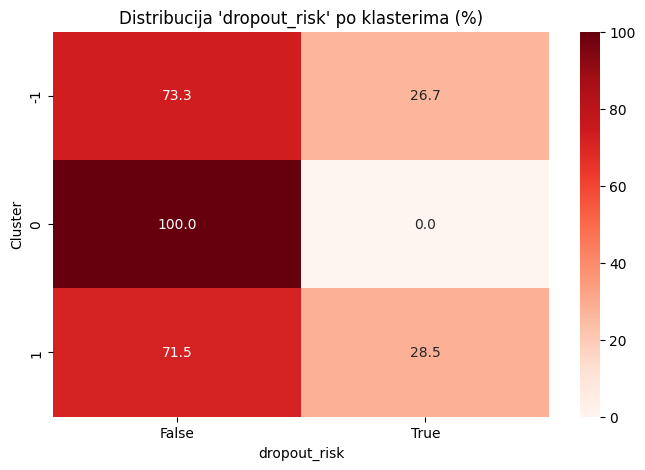

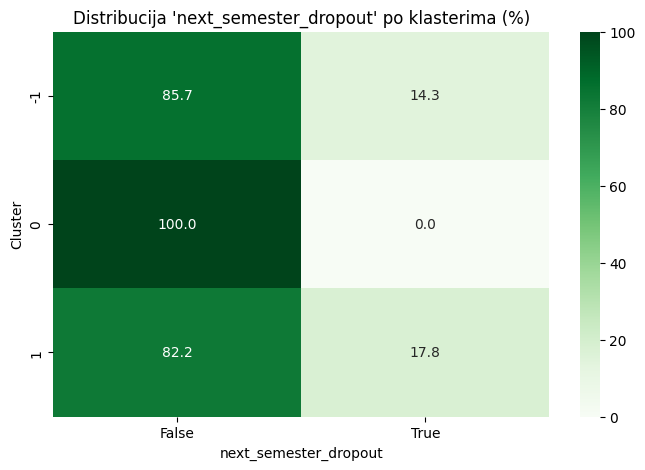

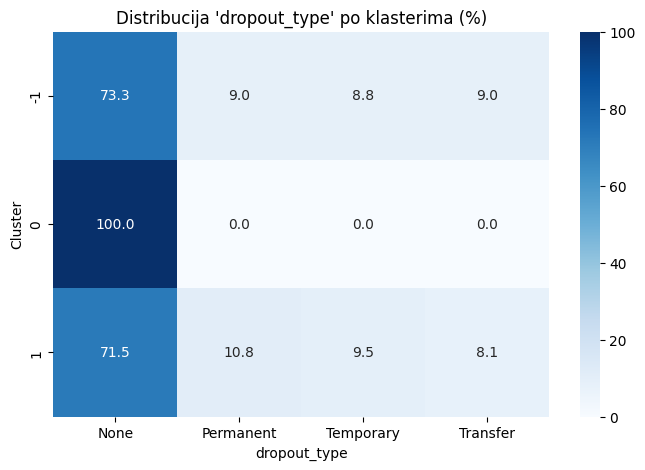

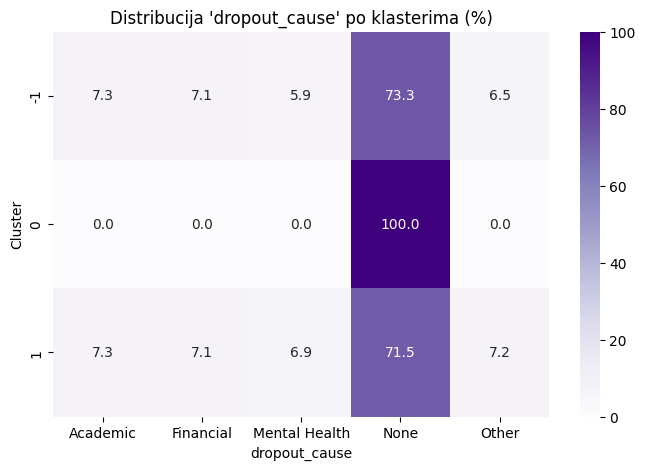

In [278]:
df_clustered = df_imputed.copy()
df_clustered['Cluster'] = cluster_labels

plot_cluster_heatmap(df_clustered, "Cluster", "dropout_risk", cmap="Reds")
plot_cluster_heatmap(df_clustered, "Cluster", "next_semester_dropout", cmap="Greens")
plot_cluster_heatmap(df_clustered, "Cluster", "dropout_type")
plot_cluster_heatmap(df_clustered, "Cluster", "dropout_cause", cmap="Purples")

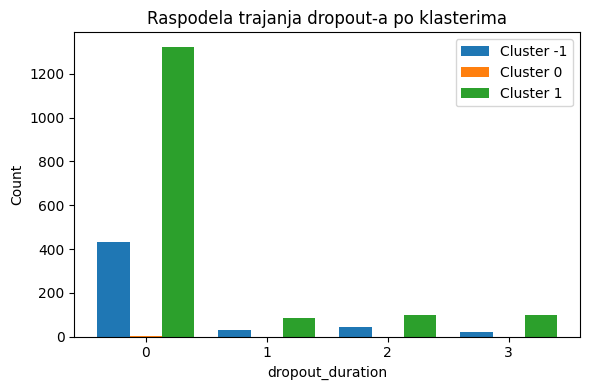

In [280]:
plot_discrete_histograms_grouped(
    df_scaled=df_HDBSCAN,
    df_original=df_original,
    cluster_col='Cluster',
    numeric_col='dropout_duration',
    title='Raspodela trajanja dropout-a po klasterima'
)

# Poređenje klasterizacija

In [87]:
def rank_clusterings(df_dict, cluster_col='Cluster', alpha_small=0.5, alpha_large=0.5, alpha_noise=0.5):
    
    results = []

    for name, df in df_dict.items():
        X = df.drop(columns=[cluster_col]).values
        labels = df[cluster_col].values

        n_total = len(labels)
        noise_mask = labels == -1
        n_noise = np.sum(noise_mask)
        fraction_noise = n_noise / n_total

        mask = labels != -1
        X_filtered = X[mask]
        labels_filtered = labels[mask]

        if len(np.unique(labels_filtered)) < 2:
            quality_score = np.nan
        else:
            sil = silhouette_score(X_filtered, labels_filtered)
            ch = calinski_harabasz_score(X_filtered, labels_filtered)
            db = davies_bouldin_score(X_filtered, labels_filtered)

            sil_scaled = max(sil, 0)
            ch_scaled = ch / (ch + 1e-9)
            db_scaled = 1 / (1 + db)
            base_score = np.mean([sil_scaled, ch_scaled, db_scaled])

            counts = np.array([np.sum(labels_filtered == l) for l in np.unique(labels_filtered)])
            total = counts.sum()
            fractions = counts / total

            small_penalty = np.mean([f for f in fractions if f < 0.05]) if np.any(fractions < 0.05) else 0
            large_penalty = np.mean([f for f in fractions if f > 0.5]) if np.any(fractions > 0.5) else 0

            noise_penalty = fraction_noise

            total_penalty = alpha_small * small_penalty + alpha_large * large_penalty + alpha_noise * noise_penalty

            quality_score = base_score * (1 - total_penalty)

        results.append({'name': name, 'quality_score': quality_score})

    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values(by='quality_score', ascending=False).reset_index(drop=True)
    return results_df

In [88]:
dfs_dict = {
    'KMeans': df_KMeans,
    #'Agglomerative sil': df_Agglomerative_sil,
    'Agglomerative dend': df_Agglomerative_dend,
    #'Divisive sil': df_Divisive_sil,
    'Divisive dend': df_Divisive_dend,
    'DBSCAN': df_DBSCAN,
    'HDBSCAN': df_HDBSCAN
}

ranked = rank_clusterings(dfs_dict)
print(ranked)

                 name  quality_score
0              KMeans       0.413105
1  Agglomerative dend       0.384673
2       Divisive dend       0.302255
3              DBSCAN       0.231778
4             HDBSCAN       0.184261


# Redukcija dimenzija

In [90]:
clustered_df = df_KMeans
clustered_df.shape

(2134, 30)

In [91]:
X=clustered_df.values

In [92]:
pca = PCA()
pca.fit(X)

explained = pca.explained_variance_ratio_

cum_var = np.cumsum(explained)

In [93]:
k90 = np.argmax(cum_var >= 0.90) + 1
k95 = np.argmax(cum_var >= 0.95) + 1

print("Broj komponenti za 90% varijanse:", k90)
print("Broj komponenti za 95% varijanse:", k95)

Broj komponenti za 90% varijanse: 18
Broj komponenti za 95% varijanse: 22


Optimalni broj komponenti prema Scree plotu: 15


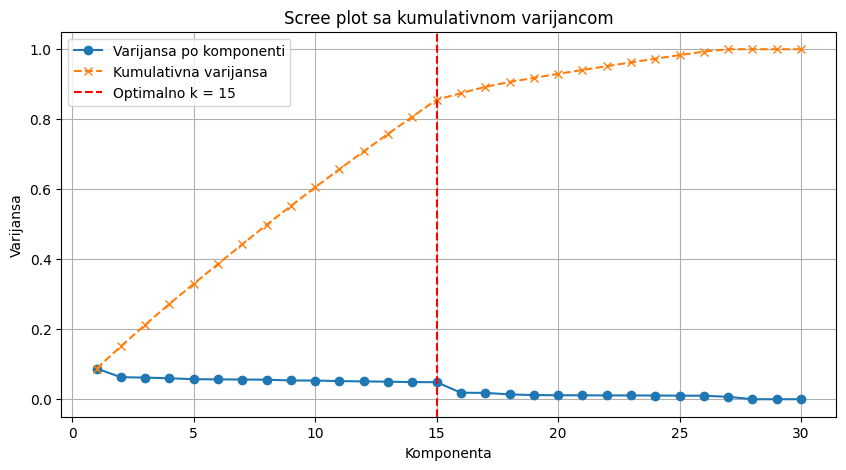

In [94]:
from kneed import KneeLocator

knee = KneeLocator(range(1, len(cum_var)+1), cum_var, curve='concave', direction='increasing')
optimal_k = knee.knee
print("Optimalni broj komponenti prema Scree plotu:", optimal_k)

# Crtanje Scree plot-a
plt.figure(figsize=(10,5))
plt.plot(range(1, len(explained)+1), explained, marker='o', label='Varijansa po komponenti')
plt.plot(range(1, len(cum_var)+1), cum_var, marker='x', linestyle='--', label='Kumulativna varijansa')
plt.axvline(optimal_k, color='r', linestyle='--', label=f'Optimalno k = {optimal_k}')
plt.title("Scree plot sa kumulativnom varijancom")
plt.xlabel("Komponenta")
plt.ylabel("Varijansa")
plt.legend()
plt.grid(True)
plt.show()

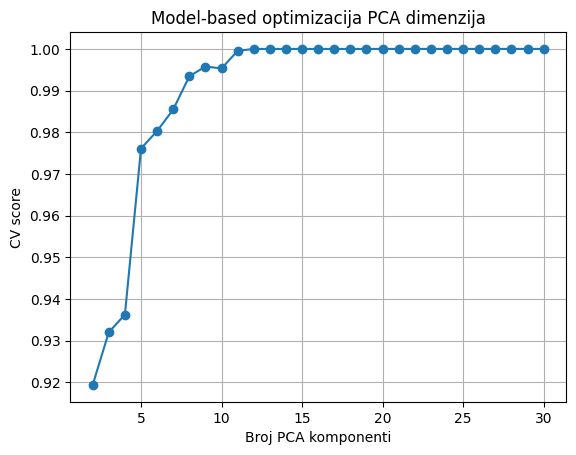

Optimalan k (prema modelu): 12


In [95]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

scores = []
components_range = range(2, 31)   # probaj 2–40 komponenti
y = clustered_df['Cluster'].values

for k in components_range:
    pca = PCA(n_components=k)
    Xp = pca.fit_transform(X)
    
    model = LogisticRegression(max_iter=2000)
    cv_score = cross_val_score(model, Xp, y, cv=5).mean()
    scores.append(cv_score)

# Iscrtavanje
plt.plot(components_range, scores, marker='o')
plt.xlabel("Broj PCA komponenti")
plt.ylabel("CV score")
plt.title("Model-based optimizacija PCA dimenzija")
plt.grid(True)
plt.show()

best_k = components_range[scores.index(max(scores))]
print("Optimalan k (prema modelu):", best_k)

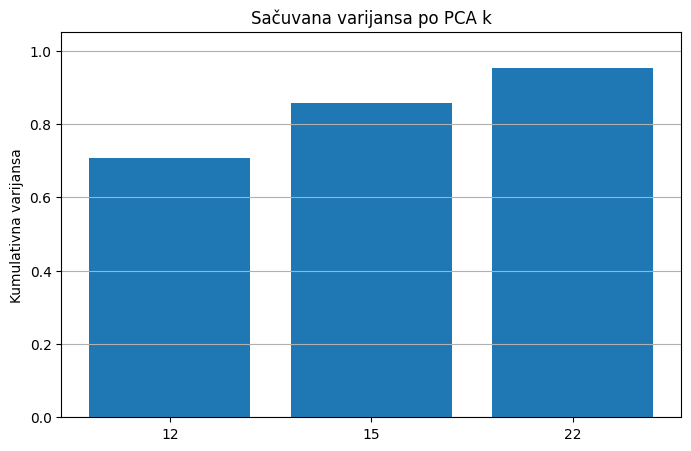

In [96]:
import numpy as np

k_values = [12, 15, 22]
cum_var_list = []

for k in k_values:
    pca = PCA(n_components=k)
    pca.fit(X)
    cum_var_list.append(np.sum(pca.explained_variance_ratio_))

plt.figure(figsize=(8,5))
plt.bar([str(k) for k in k_values], cum_var_list)
plt.ylim(0,1.05)
plt.ylabel("Kumulativna varijansa")
plt.title("Sačuvana varijansa po PCA k")
plt.grid(axis='y')
plt.show()


In [282]:
pca = PCA(n_components=22)
X_pca = pca.fit_transform(X)

df_pca = pd.DataFrame(X_pca, columns=[f'PC{i+1}' for i in range(22)])

df_pca['Cluster'] = y

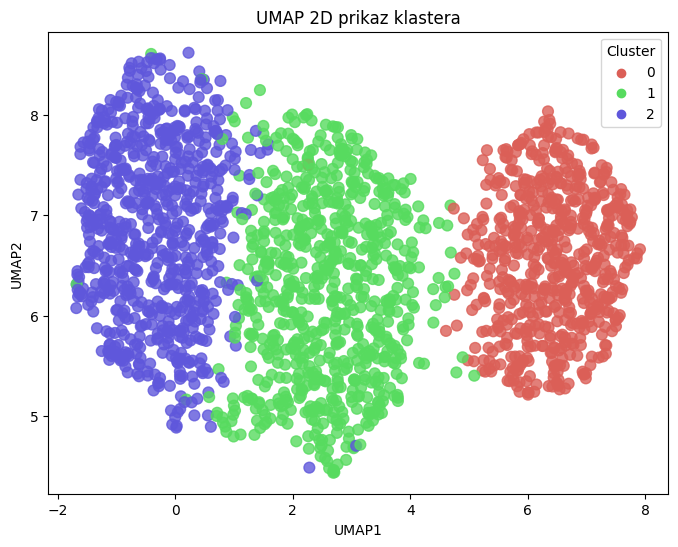

In [98]:
draw_umap_2d_3d(y, df_pca)

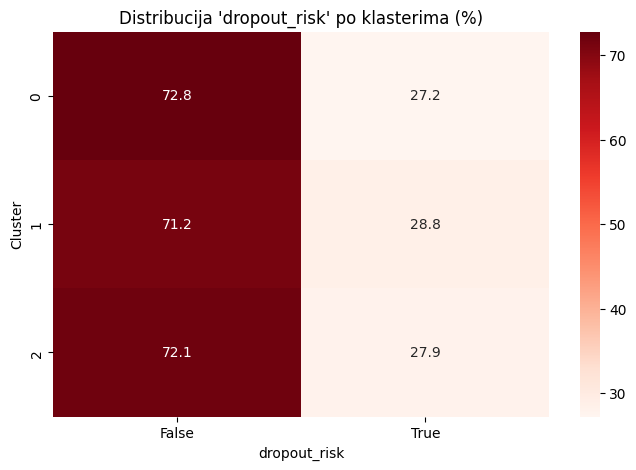

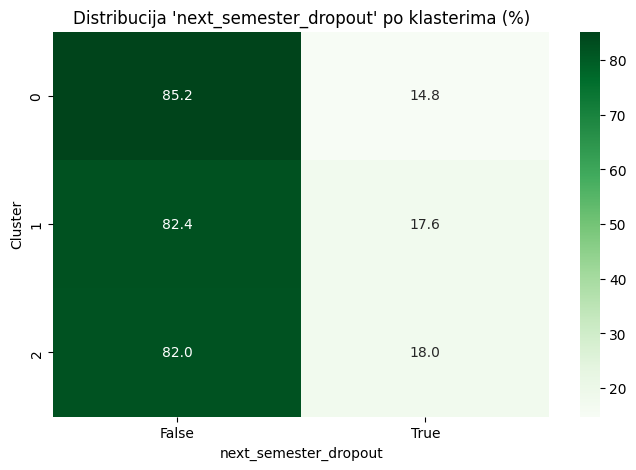

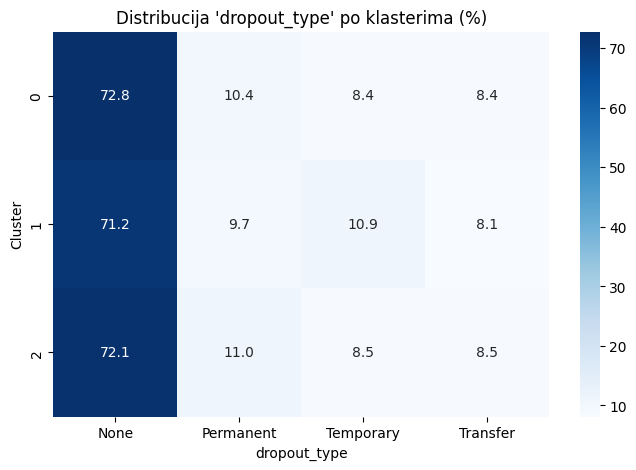

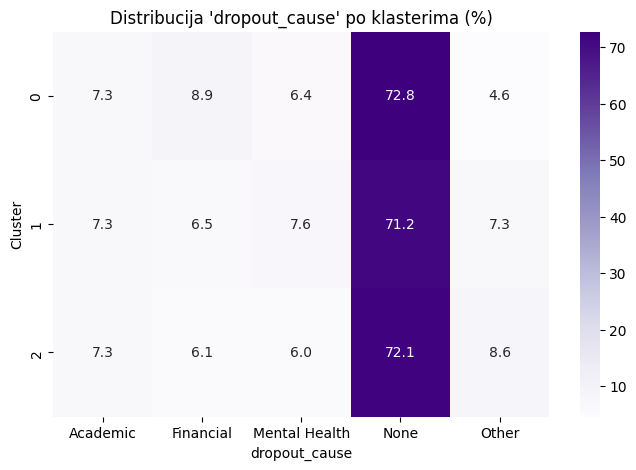

In [284]:
df_clustered = df_imputed.copy()
df_clustered['Cluster'] = y

plot_cluster_heatmap(df_clustered, "Cluster", "dropout_risk", cmap="Reds")
plot_cluster_heatmap(df_clustered, "Cluster", "next_semester_dropout", cmap="Greens")
plot_cluster_heatmap(df_clustered, "Cluster", "dropout_type")
plot_cluster_heatmap(df_clustered, "Cluster", "dropout_cause", cmap="Purples")

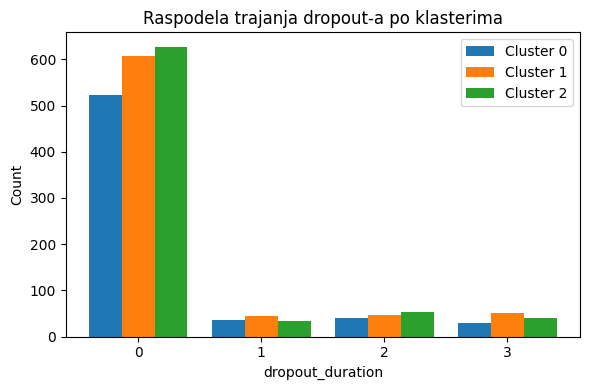

In [286]:
plot_discrete_histograms_grouped(
    df_scaled=df_pca,
    df_original=df_original,
    cluster_col='Cluster',
    numeric_col='dropout_duration',
    title='Raspodela trajanja dropout-a po klasterima'
)